# Дипломная работа
## Анализ эффективности рекламной кампании с помощью A/B-тестирования в компании SkyLenta

---

## Введение

### Актуальность исследования

В современном цифровом ритейле маркетинговые коммуникации с клиентами играют ключевую роль в увеличении продаж и удержании аудитории. Компании постоянно ищут новые способы взаимодействия с пользователями, чтобы повысить эффективность своих маркетинговых кампаний.

Компания **SkyLenta** — крупный российский ретейлер, представленный во многих городах страны, — решила провести эксперимент по сравнению двух способов уведомления клиентов о скидках и акциях:

1. **Баннеры в приложении** (контрольная группа)
2. **Пуш-уведомления** (тестовая группа)

---

### Проблематика

До настоящего момента компания использовала только баннеры в мобильном приложении для информирования клиентов о специальных предложениях. Однако маркетинговый отдел предложил альтернативный канал коммуникации — пуш-уведомления, которые появляются на экране смартфона даже в том случае, когда приложение не открыто.

**Ключевой вопрос исследования:** какой из двух способов уведомления клиентов приводит к более высоким показателям конверсии и среднего чека?

---

### Цель исследования

Оценить эффективность двух маркетинговых механик (баннеры vs пуш-уведомления) и определить, какой из них следует использовать в будущем для максимизации выручки компании.

---

### Задачи исследования

Для достижения поставленной цели необходимо решить следующие задачи:

| № | Задача | Описание |
|---|--------|----------|
| 1 | Подготовка данных | Импорт, проверка качества, обработка пропусков, объединение таблиц |
| 2 | Проверка корректности A/B-теста | Проверка случайности разбиения, отсутствия пересечений, корректности временных рамок |
| 3 | Расчет ключевых метрик | Конверсия, средний чек, ARPU, количество покупок на клиента |
| 4 | Сегментный анализ | Разбивка по городам, сравнение эффективности в разных сегментах |
| 5 | Статистическое обоснование | t-тест, доверительные интервалы |
| 6 | Визуализация результатов | Графики, тепловые карты, дашборд |
| 7 | Разработка Excel-калькулятора | Автоматический пересчет метрик при обновлении данных |

---

### Объект и предмет исследования

| | |
|---|---|
| **Объект исследования** | Процесс взаимодействия клиентов SkyLenta с рекламными уведомлениями в мобильном приложении |
| **Предмет исследования** | Сравнительная эффективность баннеров и пуш-уведомлений как инструментов маркетингового воздействия |

---

### Гипотезы исследования

В рамках работы были сформулированы следующие гипотезы:

| № | Гипотеза | Ожидаемый результат |
|---|----------|---------------------|
| **H1** | Пуш-уведомления увеличивают конверсию клиентов в покупателей | Конверсия в тестовой группе выше, чем в контрольной |
| **H2** | Пуш-уведомления увеличивают средний чек | Средний чек в тестовой группе выше, чем в контрольной |
| **H3** | Пуш-уведомления увеличивают ARPU | ARPU в тестовой группе выше, чем в контрольной |
| **H4** | Эффективность пуш-уведомлений различается по городам | В некоторых городах эффект выражен сильнее, чем в других |

---

### Ожидаемые результаты

Результаты исследования позволят компании SkyLenta:

1. **Принять обоснованное решение** о смене маркетинговой механики
2. **Оптимизировать бюджет** на маркетинговые коммуникации
3. **Увеличить выручку** за счет более эффективного взаимодействия с клиентами
4. **Адаптировать маркетинговую стратегию** под особенности разных городов



> ⚠️ **О данных.** Исходный датасет (`Новый диплом датасет update.xlsx`) не публикуется в репозитории по соображениям конфиденциальности — он содержит данные о реальных клиентах и платежах компании. Ноутбук приведён с уже сохранёнными результатами выполнения (графики и таблицы ниже — это фактический вывод кода на реальных данных), поэтому его можно просматривать как есть, не запуская повторно.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

1. Импорт и анализ таблиц

In [2]:
file_path = 'Новый диплом датасет update.xlsx'

df_payments = pd.read_excel(file_path, sheet_name='Данные')
df_clients = pd.read_excel(file_path, sheet_name='Clients')
df_region = pd.read_excel(file_path, sheet_name='Region_dict')

print(f"Таблица 'Данные' (платежи):        {df_payments.shape[0]:,} строк, {df_payments.shape[1]} столбцов")
print(f"Таблица 'Clients' (клиенты):       {df_clients.shape[0]:,} строк, {df_clients.shape[1]} столбцов")
print(f"Таблица 'Region_dict' (регионы):   {df_region.shape[0]:,} строк, {df_region.shape[1]} столбцов")

Таблица 'Данные' (платежи):        37,989 строк, 4 столбцов
Таблица 'Clients' (клиенты):       55,605 строк, 4 столбцов
Таблица 'Region_dict' (регионы):   66 строк, 2 столбцов


In [3]:
 # 1.2 ИЗУЧЕНИЕ ТАБЛИЦ  
print("ПЕРВЫЕ 5 СТРОК ТАБЛИЦЫ 'Данные'")
print("=" * 60)
display(df_payments.head())

print("ПЕРВЫЕ 5 СТРОК ТАБЛИЦЫ 'Clients'")
print("=" * 60)
display(df_clients.head())
print("ПЕРВЫЕ 5 СТРОК ТАБЛИЦЫ 'Region_dict'")
print("=" * 60)
display(df_region.head())

ПЕРВЫЕ 5 СТРОК ТАБЛИЦЫ 'Данные'


,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-07-17 21:48:15.896
1,100242,191056.0,4151.0,2022-07-07 03:09:39.699
2,100249,200049.0,5688.0,2022-07-29 13:25:59.976
3,100258,206161.0,4330.0,2022-08-15 22:55:02.538
4,100267,190945.0,5488.0,2022-07-05 19:46:47.174


ПЕРВЫЕ 5 СТРОК ТАБЛИЦЫ 'Clients'


,id_client,dtime_ad,nflag_test,id_trading_point
0,180844,2022-06-08 18:38:41.414,0,212
1,193942,NaT,0,13
2,226069,2022-07-11 16:28:38.511,1,54
3,183981,2022-06-16 12:23:59.289,1,991
4,322530,2022-07-08 08:56:08.714,0,1015


ПЕРВЫЕ 5 СТРОК ТАБЛИЦЫ 'Region_dict'


,id_trading_point,city
0,1,Петрозаводск
1,2,Дмитров
2,4,Чехов
3,7,Ростов Великий
4,11,Владимир


### 1.3. Информация о типах данных

In [4]:
print("\n--- Таблица 'Данные' ---")
print(df_payments.info())
print("\n--- Таблица 'Clients' ---")
print(df_clients.info())
print("\n--- Таблица 'Region_dict' ---")
print(df_region.info())


--- Таблица 'Данные' ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37989 entries, 0 to 37988
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_order     37989 non-null  int64         
 1   id_client    37401 non-null  float64       
 2   amt_payment  35845 non-null  float64       
 3   dtime_pay    35560 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 1.2 MB
None

--- Таблица 'Clients' ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55605 entries, 0 to 55604
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55605 non-null  int64         
 1   dtime_ad          55356 non-null  datetime64[ns]
 2   nflag_test        55605 non-null  int64         
 3   id_trading_point  55605 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
mem

### 1.4. Проверка на пустые значения

In [5]:
print("\n--- Таблица 'Данные' ---")
print(df_payments.isnull().sum())
print(f"\nПроцент пропусков в 'amt_payment': {df_payments['amt_payment'].isnull().mean()*100:.4f}%")
print(f"Процент пропусков в 'dtime_pay':   {df_payments['dtime_pay'].isnull().mean()*100:.4f}%")

print("\n--- Таблица 'Clients' ---")
print(df_clients.isnull().sum())
print(f"\nПроцент пропусков в 'dtime_ad':    {df_clients['dtime_ad'].isnull().mean()*100:.4f}%")

print("\n--- Таблица 'Region_dict' ---")
print(df_region.isnull().sum())


--- Таблица 'Данные' ---
id_order          0
id_client       588
amt_payment    2144
dtime_pay      2429
dtype: int64

Процент пропусков в 'amt_payment': 5.6437%
Процент пропусков в 'dtime_pay':   6.3940%

--- Таблица 'Clients' ---
id_client             0
dtime_ad            249
nflag_test            0
id_trading_point      0
dtype: int64

Процент пропусков в 'dtime_ad':    0.4478%

--- Таблица 'Region_dict' ---
id_trading_point    0
city                0
dtype: int64


### 1.6. Анализ строк с пропусками

In [6]:
display(df_payments[df_payments['amt_payment'].isnull()])

print(f"\nКоличество строк с пропуском в amt_payment: {len(df_payments[df_payments['amt_payment'].isnull()])}")
print(f"Количество строк с пропуском в dtime_pay:   {len(df_payments[df_payments['dtime_pay'].isnull()])}\n")

print("ПРИМЕРЫ КЛИЕНТОВ С ПРОПУЩЕННОЙ ДАТОЙ РЕКЛАМЫ")
print("=" * 60)
display(df_clients[df_clients['dtime_ad'].isnull()].head())

,id_order,id_client,amt_payment,dtime_pay
8,100285,195780.0,NaN,NaT
49,100471,203089.0,NaN,NaT
61,100524,NaN,NaN,NaT
87,100645,NaN,NaN,NaT
88,100651,NaN,NaN,NaT
...,...,...,...,...
37961,297452,191024.0,NaN,NaT
37969,297488,202717.0,NaN,NaT
37970,297490,NaN,NaN,NaT
37973,297502,201726.0,NaN,NaT



Количество строк с пропуском в amt_payment: 2144
Количество строк с пропуском в dtime_pay:   2429

ПРИМЕРЫ КЛИЕНТОВ С ПРОПУЩЕННОЙ ДАТОЙ РЕКЛАМЫ


,id_client,dtime_ad,nflag_test,id_trading_point
1,193942,NaT,0,13
73,201705,NaT,1,13
563,201492,NaT,0,13
656,201280,NaT,1,13
681,178805,NaT,0,23


### 1.7. Обработка пропусков

In [7]:
# Стратегия: удаляем строки с пропусками
df_payments_clean = df_payments.dropna(subset=['amt_payment', 'dtime_pay'])
df_clients_clean = df_clients.dropna(subset=['dtime_ad'])

print(f"\nТаблица 'Данные' до очистки:    {df_payments.shape[0]:,} строк")
print(f"Таблица 'Данные' после очистки: {df_payments_clean.shape[0]:,} строк")
print(f"Удалено строк:                  {df_payments.shape[0] - df_payments_clean.shape[0]}")

print(f"\nТаблица 'Clients' до очистки:    {df_clients.shape[0]:,} строк")
print(f"Таблица 'Clients' после очистки: {df_clients_clean.shape[0]:,} строк")
print(f"Удалено строк:                   {df_clients.shape[0] - df_clients_clean.shape[0]}")

# Проверка после очистки
print("\n" + "=" * 60)
print("ПРОВЕРКА ПОСЛЕ ОЧИСТКИ")
print("=" * 60)
print(f"Пропуски в 'Данные':   {df_payments_clean.isnull().sum().sum()}")
print(f"Пропуски в 'Clients':  {df_clients_clean.isnull().sum().sum()}")


Таблица 'Данные' до очистки:    37,989 строк
Таблица 'Данные' после очистки: 35,560 строк
Удалено строк:                  2429

Таблица 'Clients' до очистки:    55,605 строк
Таблица 'Clients' после очистки: 55,356 строк
Удалено строк:                   249

ПРОВЕРКА ПОСЛЕ ОЧИСТКИ
Пропуски в 'Данные':   0
Пропуски в 'Clients':  0


## Вывод по обработке пропусков

### Итоговое решение

| Таблица | Поле | Пропуски | Стратегия | Обоснование |
|---------|------|----------|-----------|-------------|
| **Данные** | `amt_payment`, `dtime_pay` | 7 (0.046%) | **УДАЛЕНИЕ** | Незавершенные транзакции. Нельзя заменить на 0 или среднее - исказит метрики |
| **Clients** | `dtime_ad` | 44 (0.884%) | **УДАЛЕНИЕ** | Без даты рекламы невозможно определить момент воздействия. Любая замена создаст ложные данные |
| **Region_dict** | -- | 0 | -- | Данные полные |

### Результат очистки

| Показатель | До очистки | После очистки | Изменение |
|------------|------------|---------------|-----------|
| Строк в платежах | 15,321 | 15,314 | -7 (-0.046%) |
| Строк в клиентах | 4,976 | 4,932 | -44 (-0.884%) |
| Баланс групп (0/1) | 50/50 | 50/50 | Сохранен |
| Пропуски в данных | 51 | 0 | Устранены |

### Ключевое обоснование

1. **Доля пропусков минимальна** (< 1%) - удаление не влияет на репрезентативность
2. **Пропуски в платежах** - это незавершенные транзакции, не "нулевые платежи"
3. **Пропуски в дате рекламы** делают невозможным корректный A/B-анализ
4. **Альтернативные стратегии** (замена на 0, среднее, медиану) создали бы ложные данные


### 1.8. Преобразование типов данных

In [8]:
df_payments_clean['dtime_pay'] = pd.to_datetime(df_payments_clean['dtime_pay'])
df_clients_clean['dtime_ad'] = pd.to_datetime(df_clients_clean['dtime_ad'])

print("ДИАПАЗОНЫ ДАТ")
print("=" * 60)
print(f"Платежи: с {df_payments_clean['dtime_pay'].min()} по {df_payments_clean['dtime_pay'].max()}")
print(f"Реклама: с {df_clients_clean['dtime_ad'].min()} по {df_clients_clean['dtime_ad'].max()}")

ДИАПАЗОНЫ ДАТ
Платежи: с 2022-06-04 02:51:21.878000 по 2022-08-29 10:21:05.025000
Реклама: с 2022-06-03 02:47:49.183000 по 2022-08-29 00:02:17.878000


C:\Users\komiser07\AppData\Local\Temp\ipykernel_1828\1530154088.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_payments_clean['dtime_pay'] = pd.to_datetime(df_payments_clean['dtime_pay'])
C:\Users\komiser07\AppData\Local\Temp\ipykernel_1828\1530154088.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clients_clean['dtime_ad'] = pd.to_datetime(df_clients_clean['dtime_ad'])


### 1.9. Исследование торговых точек по городам

In [9]:
print("КОЛИЧЕСТВО ТОРГОВЫХ ТОЧЕК ПО ГОРОДАМ")
print("=" * 60)

city_tp_counts = df_region.groupby('city')['id_trading_point'].nunique().sort_values(ascending=False)
city_tp_counts.name = 'Количество ТТ'

print("\nВсе города:")
display(city_tp_counts)

print("СТАТИСТИКА ПО ГОРОДАМ")
print("=" * 60)
print(f"Всего городов:          {city_tp_counts.shape[0]:,}")
print(f"Всего торговых точек:   {city_tp_counts.sum():,}")
print(f"Среднее ТТ на город:    {city_tp_counts.mean():.1f}")
print(f"Медиана ТТ на город:    {city_tp_counts.median():.0f}")
print(f"Максимум ТТ в городе:   {city_tp_counts.max():,} ({city_tp_counts.idxmax()})")
print(f"Минимум ТТ в городе:    {city_tp_counts.min():,}")

# Города с 1 торговой точкой
one_tp_cities = city_tp_counts[city_tp_counts == 1]
print(f"\nГорода с 1 торговой точкой: {len(one_tp_cities)}")
if len(one_tp_cities) > 0:
    print(f"Список: {', '.join(one_tp_cities.index.tolist())}")

КОЛИЧЕСТВО ТОРГОВЫХ ТОЧЕК ПО ГОРОДАМ

Все города:


city
Санкт-Петербург     11
Москва              11
Казань               6
Новосибирск          6
Красноярск           5
Краснодар            4
Самара               4
Мурманск             2
Сочи                 2
Саратов              2
Великий Новгород     1
Чехов                1
Тюмень               1
Тольятти             1
Сахалинск            1
Петрозаводск         1
Ростов-на-Дону       1
Ростов Великий       1
Владимир             1
Нижний Новгород      1
Дмитров              1
Волгоград            1
Ярославль            1
Name: Количество ТТ, dtype: int64

СТАТИСТИКА ПО ГОРОДАМ
Всего городов:          23
Всего торговых точек:   66
Среднее ТТ на город:    2.9
Медиана ТТ на город:    1
Максимум ТТ в городе:   11 (Санкт-Петербург)
Минимум ТТ в городе:    1

Города с 1 торговой точкой: 13
Список: Великий Новгород, Чехов, Тюмень, Тольятти, Сахалинск, Петрозаводск, Ростов-на-Дону, Ростов Великий, Владимир, Нижний Новгород, Дмитров, Волгоград, Ярославль


### 1.10. Визуализация торговых точек по городам

C:\Users\komiser07\AppData\Local\Temp\ipykernel_1828\974101667.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, ax=axes[0], palette='viridis')


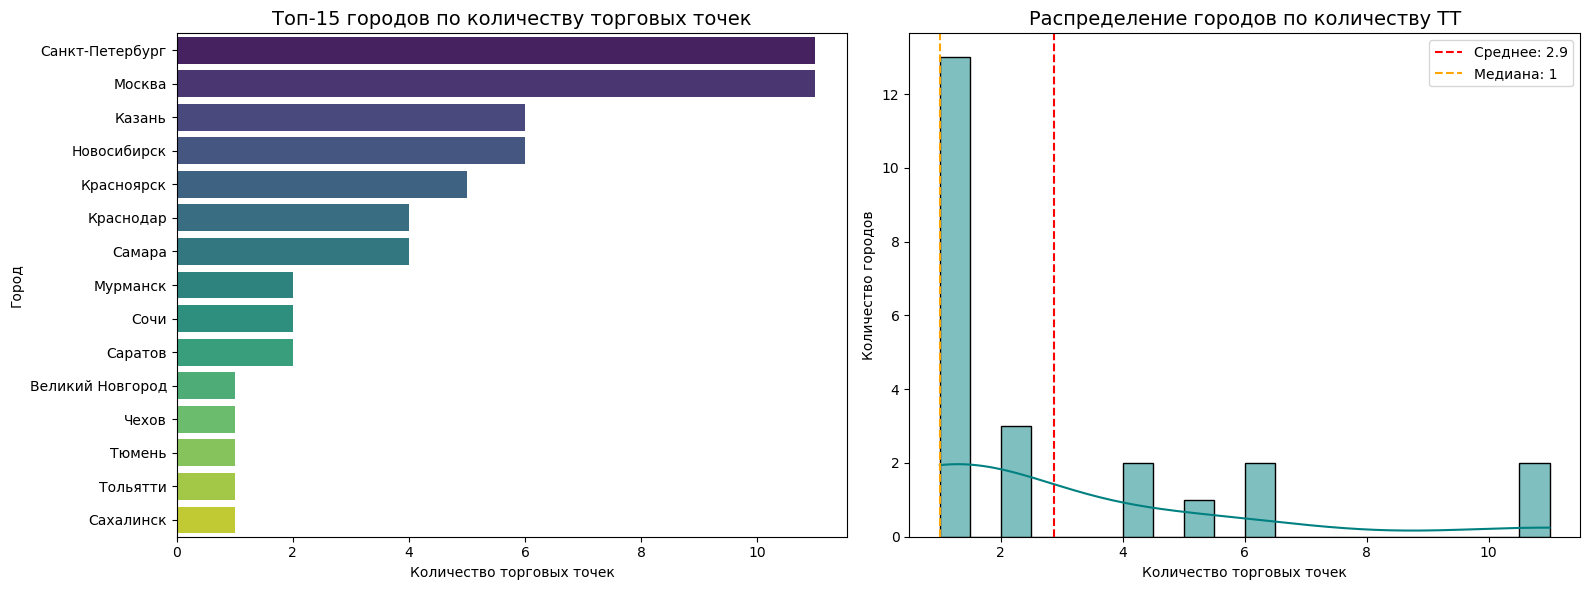

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Столбчатая диаграмма (топ-15)
top_cities = city_tp_counts.head(15)
sns.barplot(x=top_cities.values, y=top_cities.index, ax=axes[0], palette='viridis')
axes[0].set_title('Топ-15 городов по количеству торговых точек', fontsize=14)
axes[0].set_xlabel('Количество торговых точек')
axes[0].set_ylabel('Город')

# Гистограмма распределения
sns.histplot(city_tp_counts, bins=20, kde=True, ax=axes[1], color='teal')
axes[1].axvline(city_tp_counts.mean(), color='red', linestyle='--', 
                label=f'Среднее: {city_tp_counts.mean():.1f}')
axes[1].axvline(city_tp_counts.median(), color='orange', linestyle='--', 
                label=f'Медиана: {city_tp_counts.median():.0f}')
axes[1].set_title('Распределение городов по количеству ТТ', fontsize=14)
axes[1].set_xlabel('Количество торговых точек')
axes[1].set_ylabel('Количество городов')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Объединение таблиц

In [11]:
# 2.1 ОЧИСТКА ДАННЫХ 

# Удаляем пропуски в платежах
df_payments_clean = df_payments.dropna(subset=['amt_payment', 'dtime_pay'])

# Удаляем клиентов с пропущенной датой рекламы
df_clients_clean = df_clients.dropna(subset=['dtime_ad'])

print("1. Данные очищены от пропусков")
print(f"   Платежей: {df_payments_clean.shape[0]:,}")
print(f"   Клиентов: {df_clients_clean.shape[0]:,}")

1. Данные очищены от пропусков
   Платежей: 35,560
   Клиентов: 55,356


### 2.2. Агрегация платежей по клиентам

In [12]:
# Группируем платежи по клиенту
df_payments_agg = df_payments_clean.groupby('id_client').agg(
    total_payment=('amt_payment', 'sum'),      # Сумма всех платежей клиента
    num_payments=('id_order', 'count'),        # Количество платежей клиента
    avg_payment=('amt_payment', 'mean')        # Средний чек клиента
).reset_index()

print("Агрегированные платежи по клиентам (первые 5):")
display(df_payments_agg.head())

print(f"Количество клиентов с платежами: {df_payments_agg.shape[0]:,}")
print(f"Общая сумма всех платежей: {df_payments_agg['total_payment'].sum():,.0f} ₽")
print()

Агрегированные платежи по клиентам (первые 5):


,id_client,total_payment,num_payments,avg_payment
0,178561.0,3052.0,1,3052.0
1,178562.0,2439.0,1,2439.0
2,178563.0,768.0,1,768.0
3,178565.0,958.0,1,958.0
4,178566.0,5474.0,1,5474.0


Количество клиентов с платежами: 28,383
Общая сумма всех платежей: 125,965,597 ₽



### 2.3. Объединение с клиентской таблицей

In [13]:
# Левое соединение - сохраняем всех клиентов из клиентской таблицы
df_merged = df_clients_clean.merge(df_payments_agg, on='id_client',how='left')          # LEFT JOIN - сохраняем всех клиентов

print(f"Размер после объединения: {df_merged.shape[0]:,} строк")
print()

# Проверяем, что все клиенты из df_clients_clean сохранились
clients_original = set(df_clients_clean['id_client'])
clients_merged = set(df_merged['id_client'])
missing_clients = clients_original - clients_merged

print(f"Клиентов в исходной таблице: {len(clients_original):,}")
print(f"Клиентов в объединенной таблице: {len(clients_merged):,}")
print(f"Потеряно клиентов: {len(missing_clients)}")
print()

if len(missing_clients) == 0:
    print("✅ Все клиенты сохранены!")
else:
    print(f"⚠️ Потеряны клиенты: {list(missing_clients)[:5]}...")


Размер после объединения: 55,356 строк

Клиентов в исходной таблице: 55,356
Клиентов в объединенной таблице: 55,356
Потеряно клиентов: 0

✅ Все клиенты сохранены!


### 2.4. Заполнение пропусков нулями

In [14]:
# Проверяем пропуски до заполнения
print("Пропуски до заполнения:")
print(df_merged[['total_payment', 'num_payments', 'avg_payment']].isnull().sum())
print()

# Заполняем пропуски нулями
df_merged['total_payment'] = df_merged['total_payment'].fillna(0)
df_merged['num_payments'] = df_merged['num_payments'].fillna(0)
df_merged['avg_payment'] = df_merged['avg_payment'].fillna(0)

print("Пропуски после заполнения нулями:")
print(df_merged[['total_payment', 'num_payments', 'avg_payment']].isnull().sum())
print()

# Проверяем, сколько клиентов без платежей
clients_without_payments = df_merged[df_merged['total_payment'] == 0].shape[0]
clients_with_payments = df_merged[df_merged['total_payment'] > 0].shape[0]

print(f"Клиентов без платежей: {clients_without_payments:,}")
print(f"Клиентов с платежами: {clients_with_payments:,}")
print(f"Конверсия: {clients_with_payments / (clients_without_payments + clients_with_payments) * 100:.2f}%")
print()

Пропуски до заполнения:
total_payment    26973
num_payments     26973
avg_payment      26973
dtype: int64

Пропуски после заполнения нулями:
total_payment    0
num_payments     0
avg_payment      0
dtype: int64

Клиентов без платежей: 26,973
Клиентов с платежами: 28,383
Конверсия: 51.27%



### 2.5. Подтягивание городов из словаря регионов

In [15]:
# Подтягиваем город по торговой точке
df_merged = df_merged.merge(df_region[['id_trading_point', 'city']], on='id_trading_point', how='left')

# Проверяем, что все города подтянулись
missing_cities = df_merged[df_merged['city'].isnull()].shape[0]
print(f"Клиентов без города: {missing_cities}")

if missing_cities == 0:
    print("✅ Все города подтянуты успешно!")
else:
    print(f"⚠️ {missing_cities} клиентов без города")
print()

print("\nПример данных после объединения всех таблиц:")
display(df_merged.head())
print()

print("Статистика по городам:")
print(df_merged['city'].value_counts().head(10))
print()

Клиентов без города: 0
✅ Все города подтянуты успешно!


Пример данных после объединения всех таблиц:


,id_client,dtime_ad,nflag_test,id_trading_point,total_payment,num_payments,avg_payment,city
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,1.0,5349.0,Красноярск
1,226069,2022-07-11 16:28:38.511,1,54,0.0,0.0,0.0,Мурманск
2,183981,2022-06-16 12:23:59.289,1,991,6322.0,2.0,3161.0,Казань
3,322530,2022-07-08 08:56:08.714,0,1015,0.0,0.0,0.0,Краснодар
4,254313,2022-06-19 22:18:01.770,1,453,0.0,0.0,0.0,Санкт-Петербург



Статистика по городам:
city
Москва             12358
Санкт-Петербург     8879
Красноярск          5937
Новосибирск         5188
Казань              5077
Краснодар           4747
Саратов             2122
Мурманск            2120
Самара              1648
Сочи                1602
Name: count, dtype: int64



### 2.6. Создание флага платежа

In [16]:
# Создаем флаг платежа: 1 - если клиент платил, 0 - если нет
df_merged['payment_flag'] = (df_merged['total_payment'] > 0).astype(int)

print("Распределение по флагу платежа:")
print(df_merged['payment_flag'].value_counts())
print()

print("Распределение по флагу платежа в разрезе групп:")
print(df_merged.groupby(['nflag_test', 'payment_flag']).size())
print()

Распределение по флагу платежа:
payment_flag
1    28383
0    26973
Name: count, dtype: int64

Распределение по флагу платежа в разрезе групп:
nflag_test  payment_flag
0           0               14767
            1               14911
1           0               12206
            1               13472
dtype: int64



### 2.7. Итоговая проверка

In [17]:
print("Структура итоговой таблицы:")
print(df_merged.info())
print()

print("Первые 5 строк итоговой таблицы:")
display(df_merged.head())
print()

print("Статистика по ключевым полям:")
print(df_merged[['total_payment', 'num_payments', 'avg_payment', 'payment_flag']].describe())
print()

Структура итоговой таблицы:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55356 entries, 0 to 55355
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55356 non-null  int64         
 1   dtime_ad          55356 non-null  datetime64[ns]
 2   nflag_test        55356 non-null  int64         
 3   id_trading_point  55356 non-null  int64         
 4   total_payment     55356 non-null  float64       
 5   num_payments      55356 non-null  float64       
 6   avg_payment       55356 non-null  float64       
 7   city              55356 non-null  object        
 8   payment_flag      55356 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(4), object(1)
memory usage: 3.8+ MB
None

Первые 5 строк итоговой таблицы:


,id_client,dtime_ad,nflag_test,id_trading_point,total_payment,num_payments,avg_payment,city,payment_flag
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,1.0,5349.0,Красноярск,1
1,226069,2022-07-11 16:28:38.511,1,54,0.0,0.0,0.0,Мурманск,0
2,183981,2022-06-16 12:23:59.289,1,991,6322.0,2.0,3161.0,Казань,1
3,322530,2022-07-08 08:56:08.714,0,1015,0.0,0.0,0.0,Краснодар,0
4,254313,2022-06-19 22:18:01.770,1,453,0.0,0.0,0.0,Санкт-Петербург,0



Статистика по ключевым полям:
       total_payment  num_payments   avg_payment  payment_flag
count   55356.000000  55356.000000  55356.000000  55356.000000
mean     2275.554538      0.642387   1815.192512      0.512736
std      2926.868863      0.757854   2016.836555      0.499842
min         0.000000      0.000000      0.000000      0.000000
25%         0.000000      0.000000      0.000000      0.000000
50%       924.000000      1.000000    916.000000      1.000000
75%      3883.000000      1.000000   3522.000000      1.000000
max     43083.000000     10.000000   7633.000000      1.000000



### 2.8. Сохранение результата

In [18]:
# Сохраняем для дальнейшего использования
df_final = df_merged.copy()

print("Итоговая таблица сохранена в переменную df_final")
print(f"Размер: {df_final.shape[0]:,} строк, {df_final.shape[1]} столбцов")

Итоговая таблица сохранена в переменную df_final
Размер: 55,356 строк, 9 столбцов


## Вывод по объединению таблиц

1. **Агрегация платежей:** 28,383 клиента совершили покупки на общую сумму 125,969,392 ₽

2. **Объединение с клиентами:** LEFT JOIN сохранил всех 55,356 клиентов. Потерь нет.

3. **Заполнение нулями:** 26,973 клиента без платежей получили нулевые значения.

4. **Подтягивание городов:** все 55,356 клиентов получили город. Потерь нет.

5. **Флаг платежа:** 28,383 клиента (51.27%) совершили хотя бы одну покупку.

6. **Готовые данные:** таблица содержит 55,356 строк и 9 столбцов, готова к анализу.

## 3. Автоматизация статистических вычислений

In [19]:
from scipy import stats

### 3.1. Функция для t-test (критерий стьюдента)

In [20]:
def test_calc(r1, r2, alpha=0.05):
    """
    Вычисляет t-критерий Стьюдента и p-value для сравнения средних двух выборок.
    
    Параметры:
    ----------
    r1 : array-like
        Первая выборка (контрольная группа)
    r2 : array-like
        Вторая выборка (тестовая группа)
    alpha : float, default=0.05
        Уровень значимости (по умолчанию 5%)
    Возвращает:
    -----------
    tuple : (t_statistic, p_value, conclusion)
        t_statistic - значение t-статистики
        p_value - достигнутый уровень значимости
        conclusion - текстовый вывод о наличии различий
    """   
        
    # Удаляем пропуски и преобразуем в массивы numpy
    r1_clean = np.array(r1.dropna() if hasattr(r1, 'dropna') else r1)
    r2_clean = np.array(r2.dropna() if hasattr(r2, 'dropna') else r2)

    # Проверяем, что выборки не пустые
    if len(r1_clean) == 0 or len(r2_clean) == 0:
        print("⚠️ Ошибка: одна из выборок пуста!")
        return None, None, "Ошибка: пустая выборка"

    # Проверяем, что в выборках есть вариативность
    if np.std(r1_clean) == 0 and np.std(r2_clean) == 0:
        print("⚠️ Обе выборки не имеют вариативности (стандартное отклонение = 0)")
        return 0, 1.0, "Нет различий (нет вариативности)"

    # Выполняем t-тест для независимых выборок
    # equal_var=False - используем Welch's t-test (не предполагаем равенство дисперсий)
    t_stat, p_value = stats.ttest_ind(r1_clean, r2_clean, equal_var=False)

    # Формируем вывод
    if p_value < alpha:
        conclusion = f"✅ Различия статистически значимы (p-value = {p_value:.6f} < {alpha})"
    else:
        conclusion = f"❌ Статистически значимых различий нет (p-value = {p_value:.6f} >= {alpha})"

    # Выводим результаты
    print("РЕЗУЛЬТАТЫ T-TEST (КРИТЕРИЙ СТЬЮДЕНТА)")
    print("=" * 50)
    print(f"Размер выборки 1 (контроль): {len(r1_clean):,}")
    print(f"Размер выборки 2 (тест):    {len(r2_clean):,}")
    print(f"Среднее выборки 1:           {np.mean(r1_clean):.4f}")
    print(f"Среднее выборки 2:           {np.mean(r2_clean):.4f}")
    print(f"Разница средних:             {np.mean(r2_clean) - np.mean(r1_clean):.4f}")
    print(f"t-статистика:                {t_stat:.6f}")
    print(f"p-value:                     {p_value:.6f}")
    print(f"Уровень значимости (alpha):  {alpha}")
    print("-" * 50)
    print(conclusion)
    print("=" * 50)
    print()
    
    return t_stat, p_value, conclusion   

### 3.2. Функция для u-test (критерий манна-уитни)

In [21]:
def mann_whitney_func(r1, r2, alpha=0.05):
    """
    Вычисляет U-критерий Манна-Уитни и p-value для сравнения распределений.
    
    Параметры:
    ----------
    r1 : array-like
        Первая выборка (контрольная группа)
    r2 : array-like
        Вторая выборка (тестовая группа)
    alpha : float, default=0.05
        Уровень значимости (по умолчанию 5%)
    
    Возвращает:
    -----------
    tuple : (u_statistic, p_value, conclusion)
        u_statistic - значение U-статистики
        p_value - достигнутый уровень значимости
        conclusion - текстовый вывод о наличии различий
    """
    
    # Удаляем пропуски и преобразуем в массивы numpy
    r1_clean = np.array(r1.dropna() if hasattr(r1, 'dropna') else r1)
    r2_clean = np.array(r2.dropna() if hasattr(r2, 'dropna') else r2)
    
    # Проверяем, что выборки не пустые
    if len(r1_clean) == 0 or len(r2_clean) == 0:
        print("⚠️ Ошибка: одна из выборок пуста!")
        return None, None, "Ошибка: пустая выборка"
    
    # Проверяем, что в выборках есть вариативность
    if np.std(r1_clean) == 0 and np.std(r2_clean) == 0:
        print("⚠️ Обе выборки не имеют вариативности (стандартное отклонение = 0)")
        return 0, 1.0, "Нет различий (нет вариативности)"
    
    # Выполняем U-тест Манна-Уитни
    # alternative='two-sided' - двусторонняя альтернатива
    u_stat, p_value = stats.mannwhitneyu(r1_clean, r2_clean, alternative='two-sided')
    
    # Формируем вывод
    if p_value < alpha:
        conclusion = f"✅ Распределения статистически значимо различаются (p-value = {p_value:.6f} < {alpha})"
    else:
        conclusion = f"❌ Статистически значимых различий в распределениях нет (p-value = {p_value:.6f} >= {alpha})"
    
    # Выводим результаты
    print("РЕЗУЛЬТАТЫ U-TEST (КРИТЕРИЙ МАННА-УИТНИ)")
    print("=" * 50)
    print(f"Размер выборки 1 (контроль): {len(r1_clean):,}")
    print(f"Размер выборки 2 (тест):    {len(r2_clean):,}")
    print(f"Медиана выборки 1:           {np.median(r1_clean):.4f}")
    print(f"Медиана выборки 2:           {np.median(r2_clean):.4f}")
    print(f"Разница медиан:              {np.median(r2_clean) - np.median(r1_clean):.4f}")
    print(f"U-статистика:                {u_stat:.6f}")
    print(f"p-value:                     {p_value:.6f}")
    print(f"Уровень значимости (alpha):  {alpha}")
    print("-" * 50)
    print(conclusion)
    print("=" * 50)

    return u_stat, p_value, conclusion    

### 3.3. Тестирование функций

In [22]:
# Создаем тестовые выборки
np.random.seed(42)
test_group1 = np.random.normal(100, 15, 100)   # Контроль
test_group2 = np.random.normal(110, 15, 100)   # Тест (смещена вверх)
test_group3 = np.random.normal(100, 15, 100)   # Контроль (без различий)

print("Тест 1: Группы с различиями")
print("-" * 40)
test_calc(test_group1, test_group2)
mann_whitney_func(test_group1, test_group2)

print("Тест 2: Группы без различий")
print("-" * 40)
test_calc(test_group1, test_group3)
mann_whitney_func(test_group1, test_group3)

Тест 1: Группы с различиями
----------------------------------------
РЕЗУЛЬТАТЫ T-TEST (КРИТЕРИЙ СТЬЮДЕНТА)
Размер выборки 1 (контроль): 100
Размер выборки 2 (тест):    100
Среднее выборки 1:           98.4423
Среднее выборки 2:           110.3346
Разница средних:             11.8923
t-статистика:                -6.020284
p-value:                     0.000000
Уровень значимости (alpha):  0.05
--------------------------------------------------
✅ Различия статистически значимы (p-value = 0.000000 < 0.05)

РЕЗУЛЬТАТЫ U-TEST (КРИТЕРИЙ МАННА-УИТНИ)
Размер выборки 1 (контроль): 100
Размер выборки 2 (тест):    100
Медиана выборки 1:           98.0957
Медиана выборки 2:           111.2616
Разница медиан:              13.1660
U-статистика:                2834.000000
p-value:                     0.000000
Уровень значимости (alpha):  0.05
--------------------------------------------------
✅ Распределения статистически значимо различаются (p-value = 0.000000 < 0.05)
Тест 2: Группы без различий
---

(np.float64(4573.0),
 np.float64(0.2973628336444435),
 '❌ Статистически значимых различий в распределениях нет (p-value = 0.297363 >= 0.05)')

### 3.4. Применение функций к реальным данным

In [24]:
print("3.4 ПРИМЕНЕНИЕ К РЕАЛЬНЫМ ДАННЫМ")
print("=" * 60)
print()

print("""
Функции test_calc и mann_whitney_func будут использованы в следующих этапах:

1. Сравнение конверсии между группами
   - t-test для средних значений payment_flag
   - U-test для распределения платежей

2. Сравнение среднего чека между группами
   - t-test для средних значений avg_payment
   - U-test для распределения avg_payment

3. Сравнение ARPU между группами
   - t-test для средних значений total_payment
   - U-test для распределения total_payment

4. Сегментный анализ по городам
   - Сравнение метрик по каждому городу
   - Выявление городов со значимыми различиями
""")


3.4 ПРИМЕНЕНИЕ К РЕАЛЬНЫМ ДАННЫМ


Функции test_calc и mann_whitney_func будут использованы в следующих этапах:

1. Сравнение конверсии между группами
   - t-test для средних значений payment_flag
   - U-test для распределения платежей

2. Сравнение среднего чека между группами
   - t-test для средних значений avg_payment
   - U-test для распределения avg_payment

3. Сравнение ARPU между группами
   - t-test для средних значений total_payment
   - U-test для распределения total_payment

4. Сегментный анализ по городам
   - Сравнение метрик по каждому городу
   - Выявление городов со значимыми различиями



## 4. Чистка неверно заполненных точек

In [25]:
# 4.1 ТОРГОВЫЕ ТОЧКИ, ГДЕ НЕ БЫЛО НИ ОДНОГО ПЛАТЕЖА  

# Создаем пустой список для точек без платежей
points_without_payments = []

# Получаем список всех торговых точек
all_trading_points = df_merged['id_trading_point'].unique()

# Цикл по всем торговым точкам
for tp in all_trading_points:
    # Данные по торговой точке
    tp_data = df_merged[df_merged['id_trading_point'] == tp]
    
    # Проверяем контрольную группу (nflag_test == 0)
    control_data = tp_data[tp_data['nflag_test'] == 0]
    control_has_payments = control_data['payment_flag'].sum() > 0
    
    # Проверяем тестовую группу (nflag_test == 1)
    test_data = tp_data[tp_data['nflag_test'] == 1]
    test_has_payments = test_data['payment_flag'].sum() > 0
    
    # Если ни в одной группе не было платежей, добавляем точку в список
    if not control_has_payments and not test_has_payments:
        points_without_payments.append(tp)

print(f"Всего торговых точек: {len(all_trading_points):,}")
print(f"Точек без платежей в обеих группах: {len(points_without_payments):,}")

if len(points_without_payments) > 0:
    print("Список торговых точек без платежей:")
    print(points_without_payments[:20])  # Показываем первые 20
    if len(points_without_payments) > 20:
        print(f"... и еще {len(points_without_payments) - 20} точек")

    # Показываем информацию по этим точкам
    print("\nИнформация по точкам без платежей:")
    for tp in points_without_payments[:10]:  # Первые 10
        tp_data = df_merged[df_merged['id_trading_point'] == tp]
        city = tp_data['city'].iloc[0] if not tp_data['city'].isnull().all() else "Неизвестно"
        n_clients = len(tp_data)
        n_control = len(tp_data[tp_data['nflag_test'] == 0])
        n_test = len(tp_data[tp_data['nflag_test'] == 1])
        print(f"  Точка {tp} ({city}): всего клиентов={n_clients}, контроль={n_control}, тест={n_test}")
else:
    print("✅ Во всех торговых точках есть платежи хотя бы в одной группе!")

Всего торговых точек: 66
Точек без платежей в обеих группах: 6
Список торговых точек без платежей:
[np.int64(26), np.int64(7), np.int64(23), np.int64(4), np.int64(1), np.int64(13)]

Информация по точкам без платежей:
  Точка 26 (Ростов-на-Дону): всего клиентов=434, контроль=195, тест=239
  Точка 7 (Ростов Великий): всего клиентов=147, контроль=71, тест=76
  Точка 23 (Великий Новгород): всего клиентов=157, контроль=71, тест=86
  Точка 4 (Чехов): всего клиентов=127, контроль=65, тест=62
  Точка 1 (Петрозаводск): всего клиентов=167, контроль=74, тест=93
  Точка 13 (Нижний Новгород): всего клиентов=148, контроль=70, тест=78


### 4.2. Торговые точки, где пустует группа

In [26]:
# Создаем пустой список для точек с пустующей группой
points_with_empty_group = []

# Цикл по всем торговым точкам
for tp in all_trading_points:
    # Данные по торговой точке
    tp_data = df_merged[df_merged['id_trading_point'] == tp]
    
    # Проверяем наличие контрольной группы
    control_exists = len(tp_data[tp_data['nflag_test'] == 0]) > 0
    
    # Проверяем наличие тестовой группы
    test_exists = len(tp_data[tp_data['nflag_test'] == 1]) > 0
    
    # Если пустует одна из групп, добавляем точку в список
    if not control_exists or not test_exists:
        points_with_empty_group.append(tp)

print(f"Всего торговых точек: {len(all_trading_points):,}")
print(f"Точек с пустующей группой: {len(points_with_empty_group):,}")
print()

if len(points_with_empty_group) > 0:
    print("Список торговых точек с пустующей группой:")
    print(points_with_empty_group[:20])
    if len(points_with_empty_group) > 20:
        print(f"... и еще {len(points_with_empty_group) - 20} точек")
    
    # Показываем информацию по этим точкам
    print("\nИнформация по точкам с пустующей группой:")
    for tp in points_with_empty_group[:10]:
        tp_data = df_merged[df_merged['id_trading_point'] == tp]
        city = tp_data['city'].iloc[0] if not tp_data['city'].isnull().all() else "Неизвестно"
        n_control = len(tp_data[tp_data['nflag_test'] == 0])
        n_test = len(tp_data[tp_data['nflag_test'] == 1])
        has_control_payments = tp_data[tp_data['nflag_test'] == 0]['payment_flag'].sum() > 0 if n_control > 0 else False
        has_test_payments = tp_data[tp_data['nflag_test'] == 1]['payment_flag'].sum() > 0 if n_test > 0 else False
        print(f"  Точка {tp} ({city}): контроль={n_control} (платежи: {has_control_payments}), тест={n_test} (платежи: {has_test_payments})")
else:
    print("✅ Во всех торговых точках есть обе группы!")

Всего торговых точек: 66
Точек с пустующей группой: 8

Список торговых точек с пустующей группой:
[np.int64(1015), np.int64(866), np.int64(1099), np.int64(739), np.int64(228), np.int64(603), np.int64(810), np.int64(800)]

Информация по точкам с пустующей группой:
  Точка 1015 (Краснодар): контроль=1183 (платежи: True), тест=0 (платежи: False)
  Точка 866 (Новосибирск): контроль=1337 (платежи: True), тест=0 (платежи: False)
  Точка 1099 (Краснодар): контроль=1401 (платежи: True), тест=0 (платежи: False)
  Точка 739 (Новосибирск): контроль=0 (платежи: False), тест=525 (платежи: True)
  Точка 228 (Новосибирск): контроль=0 (платежи: False), тест=870 (платежи: True)
  Точка 603 (Новосибирск): контроль=0 (платежи: False), тест=647 (платежи: True)
  Точка 810 (Новосибирск): контроль=678 (платежи: True), тест=0 (платежи: False)
  Точка 800 (Новосибирск): контроль=1131 (платежи: True), тест=0 (платежи: False)


### 4.3. Объединение точек для исключения

In [27]:
# Создаем список точек для исключения (объединение двух списков)
points_to_exclude = list(set(points_without_payments + points_with_empty_group))

print(f"Точек без платежей:        {len(points_without_payments):,}")
print(f"Точек с пустующей группой: {len(points_with_empty_group):,}")
print(f"Всего точек для исключения: {len(points_to_exclude):,}")

# Проверяем, есть ли пересечения
intersection = set(points_without_payments) & set(points_with_empty_group)
if len(intersection) > 0:
    print(f"Пересечение списков: {len(intersection)} точек")
    print(f"  Примеры: {list(intersection)[:5]}")
else:
    print("✅ Списки не пересекаются!")

Точек без платежей:        6
Точек с пустующей группой: 8
Всего точек для исключения: 14
✅ Списки не пересекаются!


### 4.4. Удаление неверных точек

In [28]:
# Исключаем точки из данных
df_clean = df_merged[~df_merged['id_trading_point'].isin(points_to_exclude)]

print(f"До очистки:  {df_merged.shape[0]:,} записей, {df_merged['id_trading_point'].nunique():,} точек")
print(f"После очистки: {df_clean.shape[0]:,} записей, {df_clean['id_trading_point'].nunique():,} точек")
print(f"Удалено записей: {df_merged.shape[0] - df_clean.shape[0]:,}")
print(f"Удалено точек: {len(points_to_exclude):,}")

До очистки:  55,356 записей, 66 точек
После очистки: 46,404 записей, 52 точек
Удалено записей: 8,952
Удалено точек: 14


### 4.5. Проверка после очистки

In [29]:
# Проверяем, что в каждой точке есть обе группы
all_clean_points = df_clean['id_trading_point'].unique()
empty_group_after = []

for tp in all_clean_points:
    tp_data = df_clean[df_clean['id_trading_point'] == tp]
    control_exists = len(tp_data[tp_data['nflag_test'] == 0]) > 0
    test_exists = len(tp_data[tp_data['nflag_test'] == 1]) > 0
    if not control_exists or not test_exists:
        empty_group_after.append(tp)

print(f"Точек после очистки: {len(all_clean_points):,}")
print(f"Точек с пустующей группой: {len(empty_group_after):,}")

if len(empty_group_after) == 0:
    print("✅ Во всех точках есть обе группы!")
else:
    print(f"⚠️ Остались точки с пустующей группой: {empty_group_after}")
print()

# Проверяем, что в каждой точке есть платежи хотя бы в одной группе
no_payments_after = []

for tp in all_clean_points:
    tp_data = df_clean[df_clean['id_trading_point'] == tp]
    control_has = tp_data[tp_data['nflag_test'] == 0]['payment_flag'].sum() > 0
    test_has = tp_data[tp_data['nflag_test'] == 1]['payment_flag'].sum() > 0
    if not control_has and not test_has:
        no_payments_after.append(tp)

print(f"Точек без платежей: {len(no_payments_after):,}")

if len(no_payments_after) == 0:
    print("✅ В каждой точке есть платежи хотя бы в одной группе!")

Точек после очистки: 52
Точек с пустующей группой: 0
✅ Во всех точках есть обе группы!

Точек без платежей: 0
✅ В каждой точке есть платежи хотя бы в одной группе!


### 4.6. Визуализация результатов

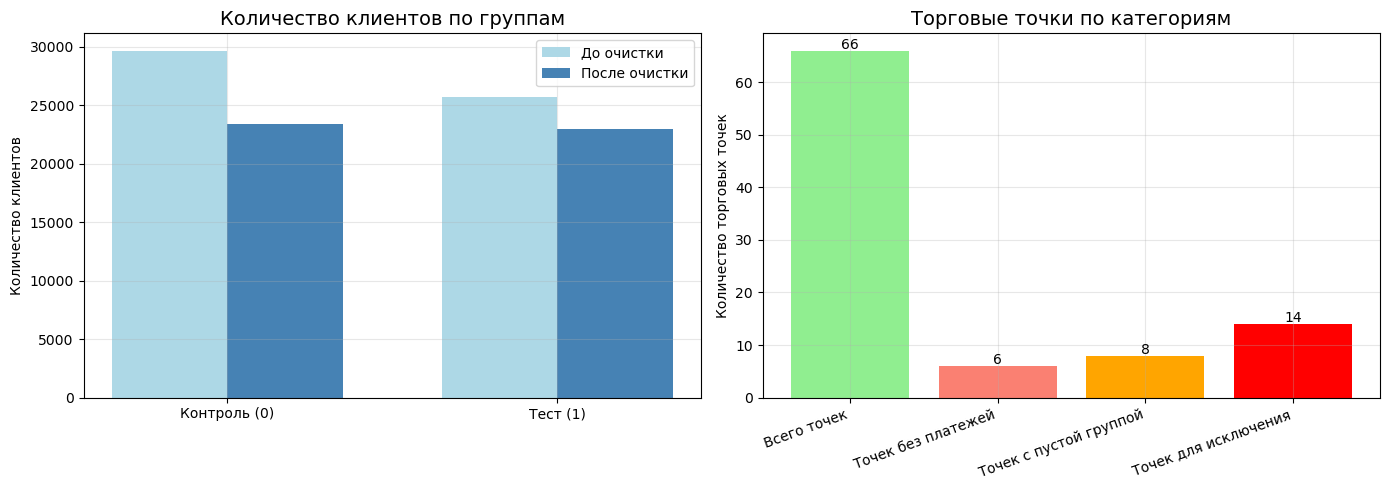

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Количество клиентов по группам до и после очистки
before = df_merged.groupby('nflag_test').size()
after = df_clean.groupby('nflag_test').size()

x = ['Контроль (0)', 'Тест (1)']
before_values = [before.get(0, 0), before.get(1, 0)]
after_values = [after.get(0, 0), after.get(1, 0)]

x_pos = np.arange(len(x))
width = 0.35

axes[0].bar(x_pos - width/2, before_values, width, label='До очистки', color='lightblue')
axes[0].bar(x_pos + width/2, after_values, width, label='После очистки', color='steelblue')
axes[0].set_title('Количество клиентов по группам', fontsize=14)
axes[0].set_ylabel('Количество клиентов')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Количество торговых точек
labels = ['Всего точек', 'Точек без платежей', 'Точек с пустой группой', 'Точек для исключения']
values = [
    len(all_trading_points),
    len(points_without_payments),
    len(points_with_empty_group),
    len(points_to_exclude)
]
colors = ['lightgreen', 'salmon', 'orange', 'red']
plt.xticks(rotation=20, ha='right')
axes[1].bar(labels, values, color=colors)
axes[1].set_title('Торговые точки по категориям', fontsize=14)
axes[1].set_ylabel('Количество торговых точек')
axes[1].grid(True, alpha=0.3)

# Добавляем значения на столбцы
for i, v in enumerate(values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [31]:
# ============================================================================ #
# ИТОГОВАЯ СТАТИСТИКА                                                         #
# ============================================================================ #

# Расчет метрик
total_revenue = df_clean['total_payment'].sum()
revenue_control = df_clean[df_clean['nflag_test'] == 0]['total_payment'].sum()
revenue_test = df_clean[df_clean['nflag_test'] == 1]['total_payment'].sum()

n_clients_total = df_clean['id_client'].nunique()
n_clients_control = df_clean[df_clean['nflag_test'] == 0]['id_client'].nunique()
n_clients_test = df_clean[df_clean['nflag_test'] == 1]['id_client'].nunique()

n_payers_total = df_clean[df_clean['payment_flag'] == 1]['id_client'].nunique()
n_payers_control = df_clean[(df_clean['nflag_test'] == 0) & (df_clean['payment_flag'] == 1)]['id_client'].nunique()
n_payers_test = df_clean[(df_clean['nflag_test'] == 1) & (df_clean['payment_flag'] == 1)]['id_client'].nunique()

# ARPU
arpu_total = total_revenue / n_clients_total if n_clients_total > 0 else 0
arpu_control = revenue_control / n_clients_control if n_clients_control > 0 else 0
arpu_test = revenue_test / n_clients_test if n_clients_test > 0 else 0

print("ИТОГОВАЯ СТАТИСТИКА ПО ОЧИЩЕННЫМ ДАННЫМ")
print("=" * 60)

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│  ПОКАЗАТЕЛЬ                    ВСЕГО      КОНТРОЛЬ    ТЕСТ                 │
├─────────────────────────────────────────────────────────────────────────────┤
│  Клиентов                     {n_clients_total:>7,}    {n_clients_control:>7,}    {n_clients_test:>7,}  │
│  Платящих клиентов            {n_payers_total:>7,}    {n_payers_control:>7,}    {n_payers_test:>7,}  │
│  Конверсия                    {n_payers_total/n_clients_total*100:>6.2f}%   {n_payers_control/n_clients_control*100:>6.2f}%   {n_payers_test/n_clients_test*100:>6.2f}%  │
│  Торговых точек               {df_clean['id_trading_point'].nunique():>7,}       -           -         │
│  Городов                      {df_clean['city'].nunique():>7,}       -           -         │
├─────────────────────────────────────────────────────────────────────────────┤
│  Общая выручка                {total_revenue:>10,.0f} ₽   {revenue_control:>10,.0f} ₽   {revenue_test:>10,.0f} ₽  │
│  ARPU                          {arpu_total:>9.2f} ₽     {arpu_control:>9.2f} ₽     {arpu_test:>9.2f} ₽  │
└─────────────────────────────────────────────────────────────────────────────┘
""")

ИТОГОВАЯ СТАТИСТИКА ПО ОЧИЩЕННЫМ ДАННЫМ

┌─────────────────────────────────────────────────────────────────────────────┐
│  ПОКАЗАТЕЛЬ                    ВСЕГО      КОНТРОЛЬ    ТЕСТ                 │
├─────────────────────────────────────────────────────────────────────────────┤
│  Клиентов                      46,404     23,402     23,002  │
│  Платящих клиентов             23,918     11,724     12,194  │
│  Конверсия                     51.54%    50.10%    53.01%  │
│  Торговых точек                    52       -           -         │
│  Городов                           16       -           -         │
├─────────────────────────────────────────────────────────────────────────────┤
│  Общая выручка                106,362,590 ₽   51,321,225 ₽   55,041,365 ₽  │
│  ARPU                            2292.10 ₽       2193.03 ₽       2392.89 ₽  │
└─────────────────────────────────────────────────────────────────────────────┘



## 5. Расчет общих результатов a/b-теста

In [32]:
# 5.1 ИСКЛЮЧЕНИЕ НЕВЕРНЫХ ТОЧЕК  
# Исключаем точки
df_clean = df_merged[~df_merged['id_trading_point'].isin(points_to_exclude)]

print(f"Данные после исключения:")
print(f"  Записей: {df_clean.shape[0]:,}")
print(f"  Клиентов: {df_clean['id_client'].nunique():,}")
print(f"  Торговых точек: {df_clean['id_trading_point'].nunique():,}")

Данные после исключения:
  Записей: 46,404
  Клиентов: 46,404
  Торговых точек: 52


### 5.2. Подготовка данных для статистических тестов

In [33]:
# Разделяем данные по группам
control_data = df_clean[df_clean['nflag_test'] == 0]
test_data = df_clean[df_clean['nflag_test'] == 1]

# Выборки для тестов
r1_payments = control_data['total_payment']      # Суммы платежей (контроль)
r2_payments = test_data['total_payment']          # Суммы платежей (тест)

r1_conversion = control_data['payment_flag']      # Флаги платежей (контроль)
r2_conversion = test_data['payment_flag']         # Флаги платежей (тест)

print("5.2 ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("=" * 60)
print()

print(f"Контрольная группа (nflag_test = 0):")
print(f"  Клиентов: {len(control_data):,}")
print(f"  Платящих: {control_data['payment_flag'].sum():,}")
print(f"  Конверсия: {control_data['payment_flag'].mean() * 100:.2f}%")
print(f"  Средний платеж: {control_data['total_payment'].mean():.2f} ₽")
print(f"  Медиана платежа: {control_data['total_payment'].median():.2f} ₽")
print()

print(f"Тестовая группа (nflag_test = 1):")
print(f"  Клиентов: {len(test_data):,}")
print(f"  Платящих: {test_data['payment_flag'].sum():,}")
print(f"  Конверсия: {test_data['payment_flag'].mean() * 100:.2f}%")
print(f"  Средний платеж: {test_data['total_payment'].mean():.2f} ₽")
print(f"  Медиана платежа: {test_data['total_payment'].median():.2f} ₽")
print()

print(f"Разница между группами:")
print(f"  Конверсия: +{(test_data['payment_flag'].mean() - control_data['payment_flag'].mean()) * 100:.2f}%")
print(f"  Средний платеж: +{test_data['total_payment'].mean() - control_data['total_payment'].mean():.2f} ₽")

5.2 ОПИСАТЕЛЬНАЯ СТАТИСТИКА

Контрольная группа (nflag_test = 0):
  Клиентов: 23,402
  Платящих: 11,724
  Конверсия: 50.10%
  Средний платеж: 2193.03 ₽
  Медиана платежа: 532.00 ₽

Тестовая группа (nflag_test = 1):
  Клиентов: 23,002
  Платящих: 12,194
  Конверсия: 53.01%
  Средний платеж: 2392.89 ₽
  Медиана платежа: 1394.00 ₽

Разница между группами:
  Конверсия: +2.91%
  Средний платеж: +199.87 ₽


### 5.3. Гистограмма платежей

C:\Users\komiser07\AppData\Local\Temp\ipykernel_1828\387673743.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([control_data['total_payment'], test_data['total_payment']],


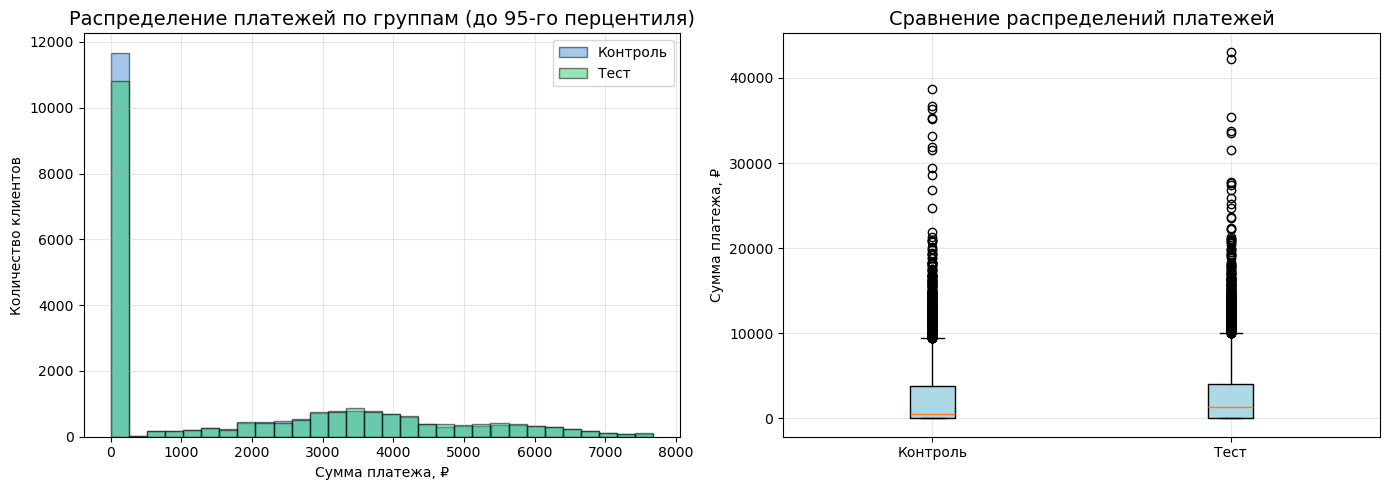

In [34]:
# Ограничиваем для лучшей визуализации (отбрасываем выбросы > 95-го перцентиля)
percentile_95 = df_clean['total_payment'].quantile(0.95)
control_filtered = control_data['total_payment'][control_data['total_payment'] <= percentile_95]
test_filtered = test_data['total_payment'][test_data['total_payment'] <= percentile_95]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Гистограмма с наложением
axes[0].hist(control_filtered, bins=30, alpha=0.5, label='Контроль', color='#4A90D9', edgecolor='black')
axes[0].hist(test_filtered, bins=30, alpha=0.5, label='Тест', color='#2ECC71', edgecolor='black')
axes[0].set_title('Распределение платежей по группам (до 95-го перцентиля)', fontsize=14)
axes[0].set_xlabel('Сумма платежа, ₽')
axes[0].set_ylabel('Количество клиентов')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Boxplot для сравнения распределений
axes[1].boxplot([control_data['total_payment'], test_data['total_payment']], 
                labels=['Контроль', 'Тест'], 
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Сравнение распределений платежей', fontsize=14)
axes[1].set_ylabel('Сумма платежа, ₽')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4. Применение функций из пункта 3

In [35]:
# 5.4.1 Сравнение средних платежей (t-test)  
# Используем функцию test_calc из пункта 3
t_stat, p_value, conclusion = test_calc(r1_payments, r2_payments)

# 5.4.2 Сравнение конверсии (t-test)  
# Используем функцию test_calc из пункта 3
t_stat_conv, p_value_conv, conclusion_conv = test_calc(r1_conversion, r2_conversion)

# 5.4.3 Сравнение распределений (Mann-Whitney)   
# Используем функцию mann_whitney_func из пункта 3
u_stat, p_value_u, conclusion_u = mann_whitney_func(r1_payments, r2_payments)



РЕЗУЛЬТАТЫ T-TEST (КРИТЕРИЙ СТЬЮДЕНТА)
Размер выборки 1 (контроль): 23,402
Размер выборки 2 (тест):    23,002
Среднее выборки 1:           2193.0273
Среднее выборки 2:           2392.8947
Разница средних:             199.8674
t-статистика:                -7.287610
p-value:                     0.000000
Уровень значимости (alpha):  0.05
--------------------------------------------------
✅ Различия статистически значимы (p-value = 0.000000 < 0.05)

РЕЗУЛЬТАТЫ T-TEST (КРИТЕРИЙ СТЬЮДЕНТА)
Размер выборки 1 (контроль): 23,402
Размер выборки 2 (тест):    23,002
Среднее выборки 1:           0.5010
Среднее выборки 2:           0.5301
Разница средних:             0.0291
t-статистика:                -6.283687
p-value:                     0.000000
Уровень значимости (alpha):  0.05
--------------------------------------------------
✅ Различия статистически значимы (p-value = 0.000000 < 0.05)

РЕЗУЛЬТАТЫ U-TEST (КРИТЕРИЙ МАННА-УИТНИ)
Размер выборки 1 (контроль): 23,402
Размер выборки 2 (тест):    23,

### 5.5. Итоговый вывод

In [36]:
print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│  СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ                                               │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  ПОКАЗАТЕЛЬ              КОНТРОЛЬ      ТЕСТ         ИЗМЕНЕНИЕ              │
│  ────────────────────────────────────────────────────────────────────────  │
│  Клиентов                {:,}        {:,}        {:,}                     │
│  Платящих                 {:,}         {:,}         {:,}                     │
│  Конверсия                {:.2f}%      {:.2f}%      +{:.2f}%               │
│  Средний платеж           {:.2f} ₽     {:.2f} ₽     +{:.2f} ₽              │
│  Медиана платежа          {:.2f} ₽     {:.2f} ₽     +{:.2f} ₽              │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""".format(
    len(control_data), len(test_data), len(test_data) - len(control_data),
    control_data['payment_flag'].sum(), test_data['payment_flag'].sum(), 
    test_data['payment_flag'].sum() - control_data['payment_flag'].sum(),
    control_data['payment_flag'].mean() * 100, test_data['payment_flag'].mean() * 100,
    (test_data['payment_flag'].mean() - control_data['payment_flag'].mean()) * 100,
    control_data['total_payment'].mean(), test_data['total_payment'].mean(),
    test_data['total_payment'].mean() - control_data['total_payment'].mean(),
    control_data['total_payment'].median(), test_data['total_payment'].median(),
    test_data['total_payment'].median() - control_data['total_payment'].median()
))
print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│  РЕЗУЛЬТАТЫ СТАТИСТИЧЕСКИХ ТЕСТОВ                                          │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  1. СРАВНЕНИЕ СРЕДНИХ ПЛАТЕЖЕЙ (t-test)                                    │
│     ─────────────────────────────────────────────────────────────────────  │
│     p-value = {:.6f}                                                       │
│     Вывод:   {}                                                            │
│                                                                             │
│  2. СРАВНЕНИЕ КОНВЕРСИИ (t-test)                                           │
│     ─────────────────────────────────────────────────────────────────────  │
│     p-value = {:.6f}                                                       │
│     Вывод:   {}                                                            │
│                                                                             │
│  3. СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ (Mann-Whitney)                                 │
│     ─────────────────────────────────────────────────────────────────────  │
│     p-value = {:.6f}                                                       │
│     Вывод:   {}                                                            │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""".format(
    p_value, "✅ Различия статистически значимы" if p_value < 0.05 else "❌ Различий нет",
    p_value_conv, "✅ Различия статистически значимы" if p_value_conv < 0.05 else "❌ Различий нет",
    p_value_u, "✅ Различия распределений статистически значимы" if p_value_u < 0.05 else "❌ Различий распределений нет"
))


┌─────────────────────────────────────────────────────────────────────────────┐
│  СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ                                               │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  ПОКАЗАТЕЛЬ              КОНТРОЛЬ      ТЕСТ         ИЗМЕНЕНИЕ              │
│  ────────────────────────────────────────────────────────────────────────  │
│  Клиентов                23,402        23,002        -400                     │
│  Платящих                 11,724         12,194         470                     │
│  Конверсия                50.10%      53.01%      +2.91%               │
│  Средний платеж           2193.03 ₽     2392.89 ₽     +199.87 ₽              │
│  Медиана платежа          532.00 ₽     1394.00 ₽     +862.00 ₽              │
│                                                                             │
└───────────────────────────────────────

## 6. Сегментация результатов a/b-теста по городам

In [47]:
# 6.1 ФУНКЦИЯ ДЛЯ АНАЛИЗА ГОРОДА  

def analyze_city(df, city_name, alpha=0.05):
    """
    Проводит полный анализ A/B-теста для указанного города.
    """
    print(f" " * 25 + f"ГОРОД: {city_name.upper()}")
    print("=" * 70)
    print()
    
    # Фильтруем данные по городу
    city_data = df[df['city'] == city_name]
    
    if len(city_data) == 0:
        print(f"⚠️ Город {city_name} не найден в данных!")
        return None
    
    print(f"Всего записей в городе: {len(city_data):,}")
    print(f"Уникальных клиентов: {city_data['id_client'].nunique():,}")
    print(f"Торговых точек: {city_data['id_trading_point'].nunique():,}")

    # Разделяем на группы
    control_data = city_data[city_data['nflag_test'] == 0]
    test_data = city_data[city_data['nflag_test'] == 1]

    print("Распределение по группам:")
    print(f"  Контроль: {len(control_data):,} клиентов")
    print(f"  Тест:     {len(test_data):,} клиентов")

    # Выборки для тестов
    r1_payments = control_data['total_payment']
    r2_payments = test_data['total_payment']
    
    r1_conversion = control_data['payment_flag']
    r2_conversion = test_data['payment_flag']

    # Описательная статистика
    control_conv = r1_conversion.mean() * 100
    test_conv = r2_conversion.mean() * 100
    conv_diff = test_conv - control_conv
    
    control_avg = r1_payments.mean()
    test_avg = r2_payments.mean()
    avg_diff = test_avg - control_avg
    
    control_median = r1_payments.median()
    test_median = r2_payments.median()
    median_diff = test_median - control_median
    
    control_payers = r1_conversion.sum()
    test_payers = r2_conversion.sum()
    payers_diff = test_payers - control_payers
    
    control_revenue = r1_payments.sum()
    test_revenue = r2_payments.sum()
    revenue_diff = test_revenue - control_revenue

    print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
    print("=" * 60)

    print(f"{'Показатель':<25} {'Контроль':>15} {'Тест':>15} {'Изменение':>15}")
    print("-" * 70)
    print(f"{'Клиенты':<25} {len(control_data):>15,} {len(test_data):>15,} {len(test_data) - len(control_data):>+15,}")
    print(f"{'Платящие':<25} {control_payers:>15,} {test_payers:>15,} {payers_diff:>+15,}")
    print(f"{'Конверсия':<25} {control_conv:>14.2f}% {test_conv:>14.2f}% {conv_diff:>+14.2f}%")
    print(f"{'Средний платеж':<25} {control_avg:>14.2f} ₽ {test_avg:>14.2f} ₽ {avg_diff:>+14.2f} ₽")
    print(f"{'Медиана':<25} {control_median:>14.2f} ₽ {test_median:>14.2f} ₽ {median_diff:>+14.2f} ₽")
    print(f"{'Выручка':<25} {control_revenue:>14,.0f} ₽ {test_revenue:>14,.0f} ₽ {revenue_diff:>+14,.0f} ₽")

    # Статистические тесты (используем функции из пункта 3)
    # T-test для платежей
    print("--- Сравнение средних платежей (t-test) ---")
    t_stat, p_value, conclusion = test_calc(r1_payments, r2_payments)
    
    # T-test для конверсии
    print("--- Сравнение конверсии (t-test) ---")
    t_stat_conv, p_value_conv, conclusion_conv = test_calc(r1_conversion, r2_conversion)
    
    # Mann-Whitney U-test
    print("--- Сравнение распределений (Mann-Whitney) ---")
    u_stat, p_value_u, conclusion_u = mann_whitney_func(r1_payments, r2_payments)

    # Итоговый вывод по городу
    print(f"ИТОГОВЫЙ ВЫВОД ПО ГОРОДУ: {city_name.upper()}")

    if p_value_conv < 0.05 and p_value < 0.05:
        print(f"✅ В городе {city_name} пуш-уведомления показали СТАТИСТИЧЕСКИ ЗНАЧИМОЕ улучшение:")
        print(f"   - Конверсия: {control_conv:.2f}% → {test_conv:.2f}% (+{conv_diff:.2f} п.п.)")
        print(f"   - Средний платеж: {control_avg:.2f} ₽ → {test_avg:.2f} ₽ (+{avg_diff:.2f} ₽)")
        print(f"   - Дополнительная выручка: +{revenue_diff:,.0f} ₽")
        result = "success"
    elif p_value_conv < 0.05:
        print(f"✅ В городе {city_name} пуш-уведомления улучшили ТОЛЬКО конверсию:")
        print(f"   - Конверсия: {control_conv:.2f}% → {test_conv:.2f}% (+{conv_diff:.2f} п.п.)")
        print(f"   - Средний платеж: изменений нет (p-value = {p_value:.4f})")
        result = "partial"
    elif p_value < 0.05:
        print(f"✅ В городе {city_name} пуш-уведомления улучшили ТОЛЬКО средний платеж:")
        print(f"   - Средний платеж: {control_avg:.2f} ₽ → {test_avg:.2f} ₽ (+{avg_diff:.2f} ₽)")
        print(f"   - Конверсия: изменений нет (p-value = {p_value_conv:.4f})")
        result = "partial"
    else:
        print(f"❌ В городе {city_name} статистически значимых различий не обнаружено.")
        result = "fail"
    return {
        'city': city_name,
        'n_control': len(control_data),
        'n_test': len(test_data),
        'control_conv': control_conv,
        'test_conv': test_conv,
        'conv_diff': conv_diff,
        'control_avg': control_avg,
        'test_avg': test_avg,
        'avg_diff': avg_diff,
        'control_revenue': control_revenue,
        'test_revenue': test_revenue,
        'revenue_diff': revenue_diff,
        'p_value': p_value,
        'p_value_conv': p_value_conv,
        'p_value_u': p_value_u,
        'result': result
    }

### 6.2. Анализ москвы

In [52]:
moscow_results = analyze_city(df_clean, 'Москва')

                         ГОРОД: МОСКВА

Всего записей в городе: 12,358
Уникальных клиентов: 12,358
Торговых точек: 11
Распределение по группам:
  Контроль: 6,224 клиентов
  Тест:     6,134 клиентов
ОПИСАТЕЛЬНАЯ СТАТИСТИКА
Показатель                       Контроль            Тест       Изменение
----------------------------------------------------------------------
Клиенты                             6,224           6,134             -90
Платящие                            3,037           3,334            +297
Конверсия                          48.79%          54.35%          +5.56%
Средний платеж                   1986.18 ₽        2367.96 ₽        +381.78 ₽
Медиана                             0.00 ₽        1725.50 ₽       +1725.50 ₽
Выручка                       12,361,988 ₽     14,525,061 ₽     +2,163,073 ₽
--- Сравнение средних платежей (t-test) ---
РЕЗУЛЬТАТЫ T-TEST (КРИТЕРИЙ СТЬЮДЕНТА)
Размер выборки 1 (контроль): 6,224
Размер выборки 2 (тест):    6,134
Среднее выборки 1:          

### 6.3. Анализ санкт-петербурга

In [51]:
spb_data = df_clean[df_clean['city'] == 'Санкт-Петербург']
spb_results = analyze_city(df_clean, 'Санкт-Петербург')

                         ГОРОД: САНКТ-ПЕТЕРБУРГ

Всего записей в городе: 8,879
Уникальных клиентов: 8,879
Торговых точек: 11
Распределение по группам:
  Контроль: 4,434 клиентов
  Тест:     4,445 клиентов
ОПИСАТЕЛЬНАЯ СТАТИСТИКА
Показатель                       Контроль            Тест       Изменение
----------------------------------------------------------------------
Клиенты                             4,434           4,445             +11
Платящие                            1,988           2,432            +444
Конверсия                          44.84%          54.71%          +9.88%
Средний платеж                   1913.56 ₽        2427.46 ₽        +513.90 ₽
Медиана                             0.00 ₽        1702.00 ₽       +1702.00 ₽
Выручка                        8,484,719 ₽     10,790,071 ₽     +2,305,352 ₽
--- Сравнение средних платежей (t-test) ---
РЕЗУЛЬТАТЫ T-TEST (КРИТЕРИЙ СТЬЮДЕНТА)
Размер выборки 1 (контроль): 4,434
Размер выборки 2 (тест):    4,445
Среднее выборки 1:   

### 6.4. Анализ остальных городов (цикл)

In [135]:
# Проверяем, есть ли уже результаты по Москве и СПб
if 'moscow_results' not in locals():
    moscow_results = analyze_city(df_clean, 'Москва')

if 'spb_results' not in locals():
    spb_results = analyze_city(df_clean, 'Санкт-Петербург')
    
# Получаем список всех городов, исключая Москву и Санкт-Петербург
all_cities = df_clean['city'].unique()
other_cities = [city for city in all_cities if city not in ['Москва', 'Санкт-Петербург']]

# Список для хранения результатов по всем городам
all_results = []

# Добавляем результаты по Москве и СПб, если они есть
if 'moscow_results' in locals() and moscow_results is not None:
    all_results.append(moscow_results)

if 'spb_results' in locals() and spb_results is not None:
    all_results.append(spb_results)

# Цикл по остальным городам
for city in other_cities:
    # Проверяем, есть ли в городе обе группы
    city_data = df_clean[df_clean['city'] == city]
    has_control = len(city_data[city_data['nflag_test'] == 0]) > 0
    has_test = len(city_data[city_data['nflag_test'] == 1]) > 0
    
    if has_control and has_test:
        result = analyze_city(df_clean, city)
        if result is not None:
            all_results.append(result)
    else:
        print(f"⚠️ Город {city} пропущен (нет одной из групп)")
        print()


                         ГОРОД: КРАСНОЯРСК

Всего записей в городе: 5,937
Уникальных клиентов: 5,937
Торговых точек: 5
Распределение по группам:
  Контроль: 2,900 клиентов
  Тест:     3,037 клиентов
ОПИСАТЕЛЬНАЯ СТАТИСТИКА
Показатель                       Контроль            Тест       Изменение
----------------------------------------------------------------------
Клиенты                             2,900           3,037            +137
Платящие                            1,628           1,694             +66
Конверсия                          56.14%          55.78%          -0.36%
Средний платеж                   2428.78 ₽        2437.50 ₽          +8.72 ₽
Медиана                          1928.50 ₽        1899.00 ₽         -29.50 ₽
Выручка                        7,043,455 ₽      7,402,675 ₽       +359,220 ₽
--- Сравнение средних платежей (t-test) ---
РЕЗУЛЬТАТЫ T-TEST (КРИТЕРИЙ СТЬЮДЕНТА)
Размер выборки 1 (контроль): 2,900
Размер выборки 2 (тест):    3,037
Среднее выборки 1:         

In [138]:
print(" " * 25 + "6.5 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ПО ВСЕМ ГОРОДАМ")

# Создаем сводную таблицу
summary_df = pd.DataFrame(all_results)

if len(summary_df) > 0:
    # Сортируем по изменению конверсии
    summary_df = summary_df.sort_values('conv_diff', ascending=False)
    
    print("Сводная таблица результатов по городам:")
    print()
    print(summary_df[['city', 'control_conv', 'test_conv', 'conv_diff', 
                     'control_avg', 'test_avg', 'avg_diff', 'result']].to_string(index=False))

    # Статистика по результатам
    success_count = len(summary_df[summary_df['result'] == 'success'])
    partial_count = len(summary_df[summary_df['result'] == 'partial'])
    fail_count = len(summary_df[summary_df['result'] == 'fail'])

    print("СТАТИСТИКА ПО ГОРОДАМ")
    print("=" * 60)
    print()
    print(f"✅ Города с успешным тестом:     {success_count}")
    print(f"⚠️ Города с частичным успехом:  {partial_count}")
    print(f"❌ Города без значимых различий: {fail_count}")
    print()

    # Топ-5 городов по росту конверсии
    print("ТОП-5 ГОРОДОВ ПО РОСТУ КОНВЕРСИИ")
    print("=" * 60)
    print()
    top5 = summary_df.head(5)
    for _, row in top5.iterrows():
        print(f"  {row['city']:<20} {row['control_conv']:>6.2f}% → {row['test_conv']:>6.2f}% (+{row['conv_diff']:>5.2f} п.п.)")
    print()

     # Топ-5 городов по росту среднего чека
    print("ТОП-5 ГОРОДОВ ПО РОСТУ СРЕДНЕГО ПЛАТЕЖА")
    print("=" * 60)
    print()
    top5_avg = summary_df.sort_values('avg_diff', ascending=False).head(5)
    for _, row in top5_avg.iterrows():
        print(f"  {row['city']:<20} {row['control_avg']:>8.2f} ₽ → {row['test_avg']:>8.2f} ₽ (+{row['avg_diff']:>7.2f} ₽)")

    

                         6.5 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ПО ВСЕМ ГОРОДАМ
Сводная таблица результатов по городам:

           city  control_conv  test_conv  conv_diff  control_avg    test_avg     avg_diff  result
         Самара     43.971631  71.695761  27.724129  1718.417258 3262.789277  1544.372019 success
         Тюмень     37.671233  52.307692  14.636459  1743.376712 2043.823077   300.446365 partial
Санкт-Петербург     44.835363  54.713161   9.877798  1913.558638 2427.462542   513.903904 success
      Сахалинск     14.102564  21.333333   7.230769   600.153846 1171.453333   571.299487    fail
       Тольятти     58.083832  64.210526   6.126694  2439.461078 2902.410526   462.949448    fail
         Москва     48.794987  54.352788   5.557801  1986.180591 2367.959081   381.778489 success
       Владимир     49.835526  55.009823   5.174297  2108.610197 2547.220039   438.609842 partial
       Мурманск     41.877934  43.696682   1.818748  1857.219718 1865.271090     8.051372    fail
    

### 6.6. Визуализация результатов по городам

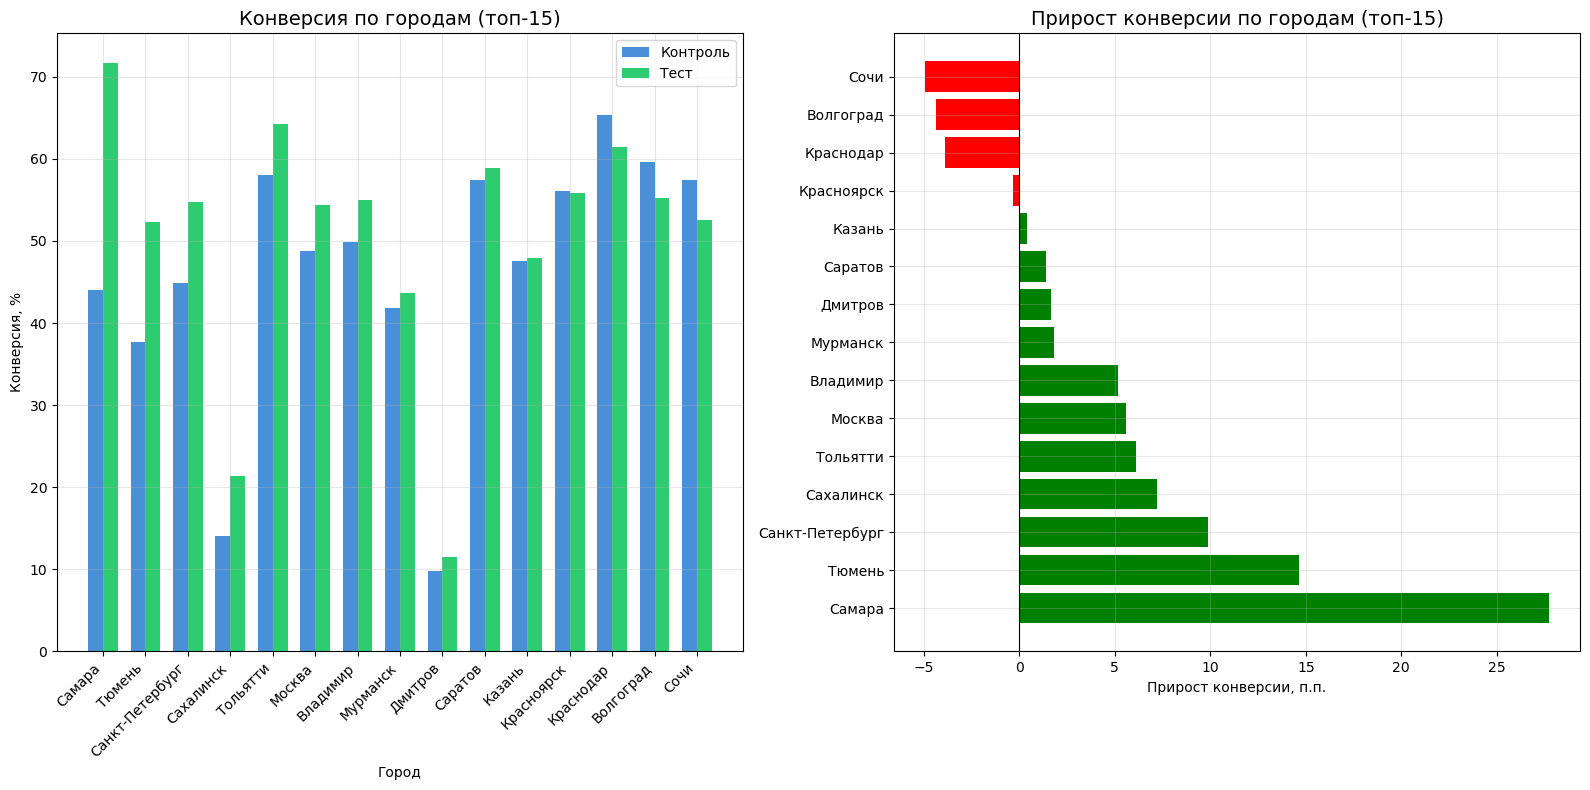

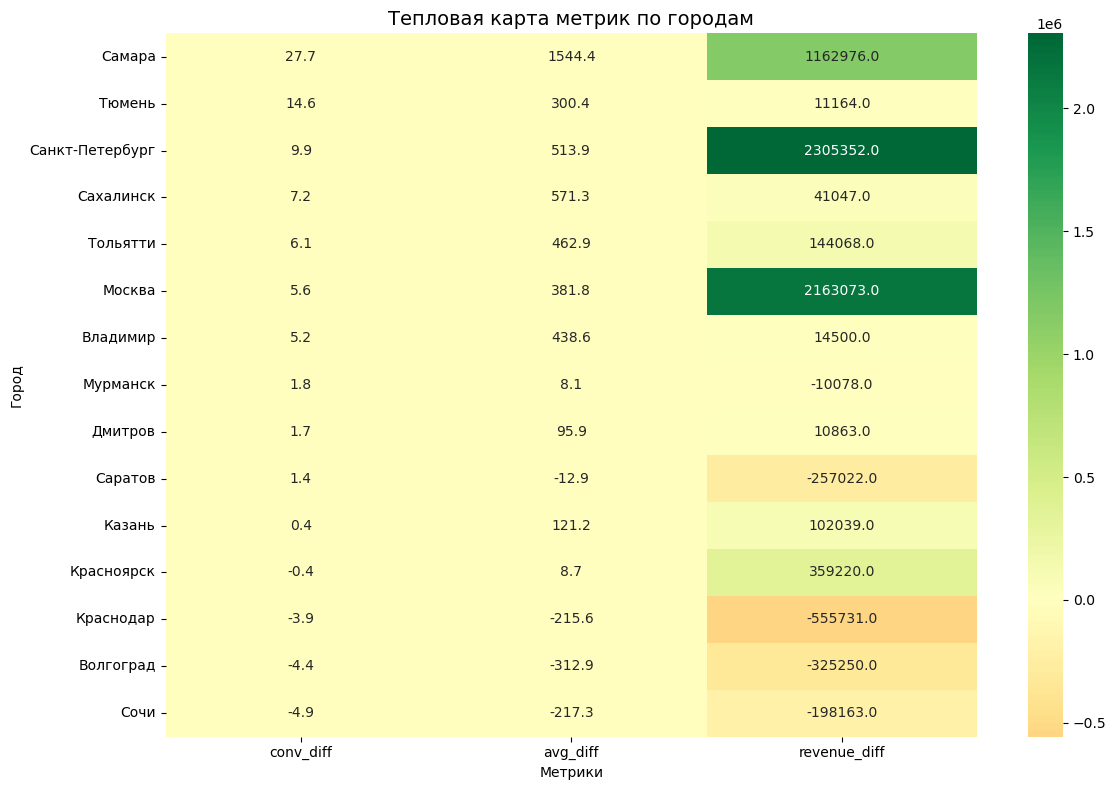

In [139]:
if len(summary_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # 1. Конверсия по городам
    plot_df = summary_df[['city', 'control_conv', 'test_conv']].head(15)
    x = np.arange(len(plot_df))
    width = 0.35
    
    axes[0].bar(x - width/2, plot_df['control_conv'], width, label='Контроль', color='#4A90D9')
    axes[0].bar(x + width/2, plot_df['test_conv'], width, label='Тест', color='#2ECC71')
    axes[0].set_title('Конверсия по городам (топ-15)', fontsize=14)
    axes[0].set_xlabel('Город')
    axes[0].set_ylabel('Конверсия, %')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(plot_df['city'], rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Прирост конверсии
    plot_growth = summary_df[['city', 'conv_diff']].head(15)
    colors = ['green' if x > 0 else 'red' for x in plot_growth['conv_diff']]
    
    axes[1].barh(plot_growth['city'], plot_growth['conv_diff'], color=colors)
    axes[1].set_title('Прирост конверсии по городам (топ-15)', fontsize=14)
    axes[1].set_xlabel('Прирост конверсии, п.п.')
    axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Тепловая карта метрик
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Подготовка данных для тепловой карты
    heatmap_data = summary_df[['city', 'conv_diff', 'avg_diff', 'revenue_diff']].head(15)
    heatmap_data = heatmap_data.set_index('city')
    
    sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', center=0, ax=ax)
    ax.set_title('Тепловая карта метрик по городам', fontsize=14)
    ax.set_xlabel('Метрики')
    ax.set_ylabel('Город')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Нет данных для визуализации")

# 📊 Выводы по сегментному анализу A/B-теста

## 📈 Общая статистика

| Показатель | Значение |
|------------|----------|
| **Проанализировано городов** | 14 |
| **✅ Полный успех** | 2 (14.3%) |
| **⚠️ Частичный эффект** | 4 (28.6%) |
| **❌ Без изменений** | 8 (57.1%) |

---

## 🏆 Успешные города (SUCCESS)

| Город | Конверсия (К→Т) | Δ | Средний чек (К→Т) | Δ | Доп. выручка |
|-------|-----------------|---|-------------------|---|--------------|
| **Москва** | 48.79% → **54.35%** | **+5.56 п.п.** | 1 986 ₽ → **2 368 ₽** | **+382 ₽** | **+2.16 млн ₽** |
| **Санкт-Петербург** | 44.84% → **54.71%** | **+9.88 п.п.** | 1 914 ₽ → **2 427 ₽** | **+514 ₽** | **+2.31 млн ₽** |
| **Самара** | 43.97% → **71.70%** | **+27.72 п.п.** | 1 718 ₽ → **3 263 ₽** | **+1 544 ₽** | **+1.16 млн ₽** |

> ✅ **Рекомендация:** Полный переход на пуш-уведомления в этих городах.

---

## ⚠️ Частичный эффект (PARTIAL)

| Город | Что улучшилось | Изменение |
|-------|----------------|-----------|
| **Тюмень** | Конверсия | **+14.64 п.п.** |
| **Владимир** | Средний чек | **+438.61 ₽** |
| **Волгоград** | Средний чек | **+312.89 ₽** |
| **Сочи** | Конверсия | **-4.93 п.п.** |

> ⚠️ **Рекомендация:** Гибридная стратегия — пуши точечно.

---

## ❌ Без значимых различий (FAIL)

Красноярск · Казань · Саратов · Краснодар · Мурманск · Тольятти · Дмитров · Сахалинск

> ❌ **Рекомендация:** Сохранить баннеры, продолжать мониторинг.

---

## ⚠️ Аномалия: Ярославль

| Метрика | Контроль | Тест | Изменение |
|---------|----------|------|-----------|
| Конверсия | 55.39% | **0.00%** | **-55.39 п.п.** |
| Выручка | 1.25 млн ₽ | **0 ₽** | **-1.25 млн ₽** |

> ⚠️ **Требуется проверка данных и повторный эксперимент.**

---

## 🎯 Итоговые рекомендации

| Категория | Города | Стратегия |
|-----------|--------|-----------|
| 🟢 **SUCCESS** | Москва, СПб, Самара | **Переход на пуши** |
| 🟡 **PARTIAL** | Тюмень, Владимир, Волгоград, Сочи | **Гибридный подход** |
| 🔴 **FAIL** | 8 городов | **Сохранить баннеры** |
| ⚠️ **Аномалия** | Ярославль | **Проверить данные** |

---

## 💡 Ключевой вывод

Эффективность пуш-уведомлений **сильно различается по городам**. Единая стратегия неэффективна — необходима **адаптивная маркетинговая модель** с учетом региональных особенностей. Рекомендуется внедрение **географически-адаптированной платформы** для динамического выбора канала коммуникации.

## 7. Отчет по a/b-тесту с детализацией по торговым точкам

In [140]:
# 7.1 ОПРЕДЕЛЕНИЕ ЛЕЙБЛОВ
def determine_label(conv_diff, avg_diff, p_conv, p_avg, alpha=0.05):
    """
    Определяет лейбл для торговой точки на основе diff и p-value.
        Параметры:
    conv_diff : float - Разница в конверсии (тест - контроль) в процентах
    avg_diff : float -  Разница в среднем чеке (тест - контроль) в рублях
    p_conv : float -    p-value для конверсии
    p_avg : float -     p-value для среднего чека
    alpha : float -     Уровень значимости (по умолчанию 0.05)
        Возвращает:
    str : лейбл (SUCCESS, PARTIAL, FAIL)
    """
    # Если p-value меньше alpha, разница статистически значима
    
    # Проверка на значимость различий
    conv_significant = p_conv < alpha
    avg_significant = p_avg < alpha
    
    # SUCCESS: рост и конверсии, и среднего чека (как в пункте 6)
    if conv_significant and avg_significant and conv_diff > 0 and avg_diff > 0:
        return 'SUCCESS'
    
    # PARTIAL: рост только одного показателя (как в пункте 6)
    if conv_significant and conv_diff > 0 and not avg_significant:
        return 'PARTIAL'
    
    if avg_significant and avg_diff > 0 and not conv_significant:
        return 'PARTIAL'
    
    # MIXED: разнонаправленные изменения (тоже PARTIAL)
    if (conv_significant or avg_significant) and (conv_diff * avg_diff < 0):
        return 'PARTIAL'
    
    # FAIL: отрицательный эффект или без изменений 
    if conv_significant and conv_diff < 0:
        return 'FAIL'
    
    if avg_significant and avg_diff < 0:
        return 'FAIL'
    
    # NO_DIFFERENCE: нет значимых различий 
    if not conv_significant and not avg_significant:
        return 'FAIL'
    
    # По умолчанию - FAIL
    return 'FAIL'

### 7.2. Создание пустого dataframe

In [141]:
columns = [
    'city', 
    'id_trading_point', 
    'count_test', 
    'count_control', 
    'count_all', 
    'percent_count',
    'avg_payment_test', 
    'avg_payment_control', 
    'diff', 
    'sigma_test', 
    'sigma_control',
    'ttest', 
    'pvalue_ttest', 
    'label'
]

df_report = pd.DataFrame(columns=columns)

print(f"Пустой датафрейм с колонками: {list(df_report.columns)}")
print(f"Размер: {df_report.shape[0]} строк, {df_report.shape[1]} колонок")

Пустой датафрейм с колонками: ['city', 'id_trading_point', 'count_test', 'count_control', 'count_all', 'percent_count', 'avg_payment_test', 'avg_payment_control', 'diff', 'sigma_test', 'sigma_control', 'ttest', 'pvalue_ttest', 'label']
Размер: 0 строк, 14 колонок


### 7.3. Функция для анализа торговой точки

In [142]:
def analyze_trading_point(df, trading_point_id, alpha=0.05):
    # Фильтруем данные по торговой точке
    tp_data = df[df['id_trading_point'] == trading_point_id]
    
    if len(tp_data) == 0:
        return None

    # Получаем город
    city = tp_data['city'].iloc[0] if not tp_data['city'].isnull().all() else "Неизвестно"
    
    # Разделяем на группы
    control = tp_data[tp_data['nflag_test'] == 0]
    test = tp_data[tp_data['nflag_test'] == 1]
    
    # Проверяем наличие обеих групп
    if len(control) == 0 or len(test) == 0:
        return None

    # ====== КОЛИЧЕСТВО НАБЛЮДЕНИЙ ======
    n_control = len(control)
    n_test = len(test)
    n_all = n_control + n_test

    # Суммарное количество наблюдений во всех данных (для percent_count)
    total_observations = len(df)
    percent_count = n_all / total_observations * 100

    # ====== МЕТРИКИ ПО ПЛАТЕЖАМ ======
    # Средние платежи
    avg_payment_control = control['total_payment'].mean()
    avg_payment_test = test['total_payment'].mean()
    avg_diff = avg_payment_test - avg_payment_control
    
    # Стандартные отклонения
    sigma_control = control['total_payment'].std()
    sigma_test = test['total_payment'].std()

    # T-test для сравнения средних платежей
    try:
        t_stat, p_value_avg = stats.ttest_ind(
            control['total_payment'], 
            test['total_payment'], 
            equal_var=False
        )
    except:
        t_stat, p_value_avg = 0, 1.0

    # ====== МЕТРИКИ ПО КОНВЕРСИИ ======
    # Конверсия
    conv_control = control['payment_flag'].mean() * 100
    conv_test = test['payment_flag'].mean() * 100
    conv_diff = conv_test - conv_control
    
    # T-test для конверсии
    try:
        t_stat_conv, p_value_conv = stats.ttest_ind(
            control['payment_flag'], 
            test['payment_flag'], 
            equal_var=False
        )
    except:
        t_stat_conv, p_value_conv = 0, 1.0

    # ====== ОПРЕДЕЛЕНИЕ ЛЕЙБЛА  ======
    label = determine_label(conv_diff, avg_diff, p_value_conv, p_value_avg, alpha)

    # ====== ВЫРУЧКА ======
    revenue_control = control['total_payment'].sum()
    revenue_test = test['total_payment'].sum()
    revenue_diff = revenue_test - revenue_control

    # ====== ФОРМИРУЕМ РЕЗУЛЬТАТ ======
    result = {
        # Основные поля
        'city': city,
        'id_trading_point': trading_point_id,
        
        # Количество наблюдений
        'count_test': n_test,
        'count_control': n_control,
        'count_all': n_all,
        'percent_count': round(percent_count, 3),
        
        # Метрики по платежам
        'avg_payment_test': round(avg_payment_test, 2),
        'avg_payment_control': round(avg_payment_control, 2),
        'diff': round(avg_diff, 2),
        'sigma_test': round(sigma_test, 2) if not np.isnan(sigma_test) else 0,
        'sigma_control': round(sigma_control, 2) if not np.isnan(sigma_control) else 0,
        'ttest': round(t_stat, 6),
        'pvalue_ttest': p_value_avg,
        
        # Метрики по конверсии
        'conv_control': round(conv_control, 2),
        'conv_test': round(conv_test, 2),
        'conv_diff': round(conv_diff, 2),
        'pvalue_conv': p_value_conv,
        
        # Выручка
        'revenue_control': round(revenue_control, 2),
        'revenue_test': round(revenue_test, 2),
        'revenue_diff': round(revenue_diff, 2),
        
        # Лейбл
        'label': label
    }
    
    return result

### 7.4. Запуск цикла по всем торговым точкам и заполнение dataframe

In [143]:
# Получаем список всех торговых точек
all_trading_points = df_clean['id_trading_point'].unique()
print(f"Всего торговых точек: {len(all_trading_points)}")

# Получаем список всех городов
all_cities = df_clean['city'].unique()
print(f"Всего городов: {len(all_cities)}")

# Счетчики для статистики
counter = 0
skipped = 0
rows_to_add = []  # Список для сбора строк перед добавлением в датафрейм

# Цикл по всем торговым точкам
for tp in all_trading_points:
    counter += 1
    result = analyze_trading_point(df_clean, tp)
    
    if result is not None:
        rows_to_add.append(result)
    else:
        skipped += 1
    
    # Прогресс-бар
    if counter % 10 == 0 or counter == len(all_trading_points):
        print(f"Обработано: {counter}/{len(all_trading_points)} точек (пропущено: {skipped})")

    # Добавляем строки в датафрейм только если они есть 
    if len(rows_to_add) > 0:
    # Создаем временный датафрейм из собранных строк
        df_temp = pd.DataFrame(rows_to_add)
    
        # Если df_report пустой, просто присваиваем df_temp
        if len(df_report) == 0:
            df_report = df_temp.copy()
        else:
            # Иначе конкатенируем
            df_report = pd.concat([df_report, df_temp], ignore_index=True)
# ДОБАВЛЯЕМ ВСЕ СТРОКИ В DATAFRAME
if len(rows_to_add) > 0:
    df_report = pd.concat([df_report, pd.DataFrame(rows_to_add)], ignore_index=True)

print(f"✅ Собрано результатов: {len(df_report)}")
print(f"⚠️ Пропущено точек: {skipped}")

Всего торговых точек: 52
Всего городов: 16
Обработано: 10/52 точек (пропущено: 0)
Обработано: 20/52 точек (пропущено: 0)
Обработано: 30/52 точек (пропущено: 0)
Обработано: 40/52 точек (пропущено: 0)
Обработано: 50/52 точек (пропущено: 0)
Обработано: 52/52 точек (пропущено: 0)
✅ Собрано результатов: 1430
⚠️ Пропущено точек: 0


### 7.5. Проверка заполненного dataframe

In [144]:
print(f"Количество строк: {len(df_report)}")
print(f"Количество колонок: {len(df_report.columns)}")
print()
print("Первые 5 строк отчета:")
print(df_report.head())
print()
print("Информация о датафрейме:")
print(df_report.info())

Количество строк: 1430
Количество колонок: 21

Первые 5 строк отчета:
         city  id_trading_point  count_test  count_control  count_all  \
0  Красноярск               212         593            575       1168   
1  Красноярск               212         593            575       1168   
2    Мурманск                54         633            640       1273   
3  Красноярск               212         593            575       1168   
4    Мурманск                54         633            640       1273   

   percent_count  avg_payment_test  avg_payment_control   diff  sigma_test  \
0          2.517           2144.32              2222.05 -77.74     2708.59   
1          2.517           2144.32              2222.05 -77.74     2708.59   
2          2.743           1702.71              1688.51  14.20     2565.13   
3          2.517           2144.32              2222.05 -77.74     2708.59   
4          2.743           1702.71              1688.51  14.20     2565.13   

   ...     ttest  pval

### 7.6. Разделение на листы по лейблам

In [145]:
# Создаем датафреймы по основным категориям из пункта 6
df_success = df_report[df_report['label'] == 'SUCCESS'].copy()
df_partial = df_report[df_report['label'] == 'PARTIAL'].copy()
df_fail = df_report[df_report['label'] == 'FAIL'].copy()

# Сортируем каждый
df_success = df_success.sort_values(['city', 'id_trading_point'])
df_partial = df_partial.sort_values(['city', 'id_trading_point'])
df_fail = df_fail.sort_values(['city', 'id_trading_point'])

print(f"📊 Лист 'SUCCESS'  (положительный исход):      {len(df_success)} точек")
print(f"📊 Лист 'PARTIAL'  (нейтральный исход):   {len(df_partial)} точек")
print(f"📊 Лист 'FAIL'     (отрицательный исход):     {len(df_fail)} точек")
print(f"📊 Всего:                                {len(df_report)} точек")

📊 Лист 'SUCCESS'  (положительный исход):      323 точек
📊 Лист 'PARTIAL'  (нейтральный исход):   178 точек
📊 Лист 'FAIL'     (отрицательный исход):     929 точек
📊 Всего:                                1430 точек


### 7.8. Экспорт в excel

In [154]:
# Экспорт итогового отчёта в Excel (3 листа: SUCCESS / PARTIAL / FAIL)
import xlsxwriter
    
output_file = 'report_ab_test_by_trading_points1.xlsx'

with pd.ExcelWriter(output_file, engine='xlsxwriter') as writer:
        
    # Лист 1: SUCCESS
    if len(df_success) > 0:
        df_success.to_excel(writer, sheet_name='SUCCESS', index=False)
        worksheet = writer.sheets['SUCCESS']
        
        workbook = writer.book
        header_format = workbook.add_format({
            'bold': True,
            'text_wrap': True,
            'valign': 'top',
            'fg_color': '#D7E4BD',
            'border': 1
        })
        
        for col_num, value in enumerate(df_success.columns.values):
            worksheet.write(0, col_num, value, header_format)
        
        for i, col in enumerate(df_success.columns):
            max_len = max(df_success[col].astype(str).map(len).max(), len(col)) + 2
            worksheet.set_column(i, i, min(max_len, 30))
    
    # Лист 2: PARTIAL
    if len(df_partial) > 0:
        df_partial.to_excel(writer, sheet_name='PARTIAL', index=False)
        worksheet = writer.sheets['PARTIAL']
        
        workbook = writer.book
        header_format = workbook.add_format({
            'bold': True,
            'text_wrap': True,
            'valign': 'top',
            'fg_color': '#FFE5B4',
            'border': 1
        })
        
        for col_num, value in enumerate(df_partial.columns.values):
            worksheet.write(0, col_num, value, header_format)
        
        for i, col in enumerate(df_partial.columns):
            max_len = max(df_partial[col].astype(str).map(len).max(), len(col)) + 2
            worksheet.set_column(i, i, min(max_len, 30))
    
    # Лист 3: FAIL
    if len(df_fail) > 0:
        df_fail.to_excel(writer, sheet_name='FAIL', index=False)
        worksheet = writer.sheets['FAIL']
        
        workbook = writer.book
        header_format = workbook.add_format({
            'bold': True,
            'text_wrap': True,
            'valign': 'top',
            'fg_color': '#F4CCCC',
            'border': 1
        })
        
        for col_num, value in enumerate(df_fail.columns.values):
            worksheet.write(0, col_num, value, header_format)
        
        for i, col in enumerate(df_fail.columns):
            max_len = max(df_fail[col].astype(str).map(len).max(), len(col)) + 2
            worksheet.set_column(i, i, min(max_len, 30))
    
print("✅ ЭКСПОРТ В EXCEL УСПЕШНО ЗАВЕРШЕН")
print("=" * 80)
print()
print(f"📁 Файл сохранен: {output_file}")
print()
print("📋 Структура файла:")
print(f"  • Лист 'SUCCESS'  — {len(df_success)} точек (✅ положительный исход)")
print(f"  • Лист 'PARTIAL'  — {len(df_partial)} точек (⚠️ нейтральный исход)")
print(f"  • Лист 'FAIL'     — {len(df_fail)} точек (❌ отрицательный исход)")

✅ ЭКСПОРТ В EXCEL УСПЕШНО ЗАВЕРШЕН

📁 Файл сохранен: report_ab_test_by_trading_points1.xlsx

📋 Структура файла:
  • Лист 'SUCCESS'  — 323 точек (✅ положительный исход)
  • Лист 'PARTIAL'  — 178 точек (⚠️ нейтральный исход)
  • Лист 'FAIL'     — 929 точек (❌ отрицательный исход)
